# 서울시 골목상권 폐업위험 조기경보
## EDA · 통계 분석 · 예측 모델링 정리

> 핵심 질문 — 다음 분기에 점포 순감소(폐업 > 개업)로 전환될 상권 × 업종은 어디이며, 무엇이 위험을 만드는가

본 문서는 분석 코드를 제외하고 **출력물과 판단만** 담음.


## 1. 분석 개요

서울시 상권 공공데이터를 사용해 요식업 점포의 폐업위험을 조기에 가려내는 것을 목적으로 함. 핵심 질문은 «다음 분기에 점포 순감소(폐업 > 개업)로 전환될 상권 × 업종은 어디이며, 무엇이 위험을 만드는가»임.

분석 단위는 상권 × 서비스업종 × 분기이며, 업종은 요식업 10종(한식음식점, 중식음식점, 일식음식점, 양식음식점, 제과점, 패스트푸드점, 치킨전문점, 분식전문점, 호프-간이주점, 커피-음료)으로 한정함. 기간은 2023년 1분기~2025년 4분기 12개 분기임. 2026년 1분기는 2025년 4분기의 라벨을 만들기 위해서만 적재하고 예측 대상 행으로는 쓰지 않음.

라벨은 «다음 분기에 문 닫은 가게가 새로 연 가게보다 많은가»임. 매출 감소가 아니라 점포 순감소를 고른 이유는, 매출은 살아남은 점포만 집계되어 낙관 편향되지만 점포 수는 빠져나간 가게를 그대로 세기 때문임.

표본은 점포 5개 이상인 칸 67,475개이고 양성률은 25.5%임. 점포 5개 미만 칸은 개·폐업이 거의 없어 라벨이 노이즈에 가까우므로 제외함.



## 2. 데이터와 전처리 판단

원천은 서울시 우리마을가게 상권분석서비스임. 추정매출은 카드 결제액 기반 추정치, 유동인구는 생활인구, 점포는 사업자등록 기반임. 따라서 «폐업»은 실제 폐점이 아니라 사업자등록 말소 시점이며, 결론의 해석 범위를 이 안으로 제한함.

집객시설 파일은 시설이 없는 경우를 빈칸으로 저장하는 방식이므로 결측이 아니라 «없음»으로 보고 0으로 채움. 원본 전체에 0 표기가 한 건도 없다는 점으로 이를 확인함.

인구는 총량 하나만 사용함. 유동인구가 상주·직장 인구를 이미 포함하므로 셋을 모두 넣으면 같은 사람을 세 번 세게 됨. 직장인구 비중을 별도로 만들어 넣어 보았으나 단변량 AUC 0.520으로 판별력이 없어 제외함.



,컬럼,결측률,판정
0,엑스좌표_값,0.0%,OK
1,영역_면적,0.0%,OK
2,총_유동인구_수,0.0%,OK
3,역세권,2.3%,OK
4,상권_변화_지표,0.0%,OK
5,당월_매출_금액,45.4%,공변량 제외 권장
6,상권_전체점포,0.0%,OK
7,운영_영업_개월_평균,0.0%,OK
8,운영개월_서울대비,0.0%,OK
9,외식물가지수,0.0%,OK


※ 매출 결측이 큰 이유는 결합 실수가 아니라, 카드 매출이 잡히지 않는 영세 칸에는 원본에 행이 없기 때문임.

[저장] 02_merged.pkl (160352, 42)

### 읽는 법

결측률 표의 «판정» 열은 결측률 구간을 셋으로 나눈 것임. 5% 이하는 그대로 쓰고, 5~30%는 주의해서 보고, 30%를 넘으면 공변량에서 빼는 것을 검토함. 결측률이 높은 변수를 공변량으로 쓰면 그 변수 때문에 표본이 통째로 날아가기 때문임.



### 해석

매출 계열의 결측이 큰 것은 결합을 잘못한 결과가 아님. 카드 매출이 잡히지 않는 영세 칸에는 원본에 아예 행이 없기 때문임. 따라서 이 결측은 «자료 누락»이 아니라 «카드 결제가 관측되지 않는 규모»라는 정보를 담고 있음. 그래서 결측 행을 버리지 않고 결측 여부를 나타내는 변수를 함께 두어, 모형이 그 사실 자체를 쓸 수 있게 함.



## 3. 라벨의 구조 — y=0 에 섞여 있는 두 상태

라벨은 «다음 분기에 순감소인가»만 묻기 때문에, y=0 은 성격이 다른 두 상태의 합임. 하나는 개업도 폐업도 없는 «변화 없음»이고, 다른 하나는 개·폐업은 있었으나 줄지는 않은 상태임.

문제는 «변화 없음»이 «위험이 없다»는 뜻이 아니라는 점임. 점포가 6개뿐인 골목 칸에서 한 분기 동안 아무 일도 일어나지 않는 것은 안전해서가 아니라 작아서임. 개·폐업은 점포 수에 비례해 일어나는 사건이므로 표본이 작으면 사건 자체가 관측되지 않을 확률이 높아짐.

그 결과 «변화 없음» 칸이 y=0 에 대량으로 쌓이고, 모형은 «위험하지 않은 조건»이 아니라 «사건이 잘 안 일어나는 조건 = 규모가 작음»을 학습하게 됨. 아래 표가 그 통로를 보여 줌.

사건이 있었던 칸만 골라 쓰는 방법은 성립하지 않음. 그러려면 다음 분기의 개·폐업 건수를 먼저 알아야 하는데 그 값이 바로 맞히려는 라벨임. 실제 운영에서도 조기경보는 지금 존재하는 모든 칸에 점수를 매겨야 하므로, «변화 없음» 칸을 버리지 않고 유지하되 규모별 분포를 측정해 남김.



,건수,비율
다음 분기 상태,,
변화 없음,29633,0.439
변화 있었으나 줄지 않음,20652,0.306
순감소,17190,0.255


y=0 50,285건 가운데 «변화 없음»이 58.9% — 절반을 넘음

,칸수,평균점포,변화없음비율,순감소율
1분위,15520,5.44,0.693,0.151
2분위,14018,7.86,0.599,0.193
3분위,12139,11.73,0.465,0.243
4분위,12718,19.56,0.298,0.308
5분위,13080,65.47,0.079,0.403


→ 상권 규모가 작은 곳에서 «변화 없음»의 빈도가 높음: 평균 점포 5.4개 구간 69.3% → 65.5개 구간 7.9%
   같은 방향으로 순감소율은 15.1% → 40.3% 로 올라감.
   즉 라벨이 규모에 끌려가는 통로가 «변화 없음»임. 5-2에서 규모를 고정해 이 영향을 걷어냄.

### 읽는 법

첫 표는 다음 분기의 상태를 세 갈래로 나눈 비율임. «변화 없음»은 개업도 폐업도 0인 칸, «변화 있었으나 줄지 않음»은 개·폐업이 있었으나 폐업이 개업을 넘지 않은 칸, «순감소»가 라벨이 1인 칸임.

두 번째 표는 점포 수 5분위별로 같은 것을 다시 센 것임. 1분위가 점포가 가장 적은 구간이고 5분위가 가장 많은 구간임. «변화없음비율» 열을 위에서 아래로 읽으면 규모가 커질 때 «아무 일도 없음»이 어떻게 변하는지 보임.



### 해석

y가 0인 칸의 절반을 넘는 수가 «변화 없음»임. 즉 라벨이 0이라는 것은 대부분 «안전하다»가 아니라 «아무 일도 관측되지 않았다»는 뜻임.

그리고 그 «아무 일도 없음»은 규모에 강하게 끌려감. 평균 점포가 5.4개인 1분위에서는 열 칸 중 일곱 칸이 «변화 없음»이지만, 65.5개인 5분위에서는 열 칸 중 한 칸도 되지 않음. 같은 방향으로 순감소율은 15.1%에서 40.3%로 올라감.

이것이 이 과제에서 가장 조심해야 하는 지점임. 아무 처리도 하지 않으면 모형은 «위험한 조건»이 아니라 «사건이 일어날 만한 크기»를 배움. 뒤에서 점포 수를 고정해 다시 재고, 사건 발생과 방향을 두 단계로 나누어 다루는 이유가 전부 여기서 나옴.



## 4. 기초 탐색과 상권유형별 차이

상권유형별·자치구별 순감소율을 집계하고, 집단 간 차이를 카이제곱과 Kruskal-Wallis로 검정함. 표본이 수만 건이라 p-value는 거의 항상 유의하게 나오므로 효과크기(Cramér's V, ε²)를 함께 보고함.

공변량 사이의 상관도 함께 확인함. 트리 계열 모형에서 상관은 예측을 망치지 않으나 해석을 망침 — SHAP이 상관된 두 변수 사이에 기여를 쪼개 나눠 가져 각각의 중요도가 실제보다 낮게 보임. 따라서 뒤의 SHAP 순위를 읽을 때 상관이 큰 쌍은 한 덩어리로 보아야 함.



상권유형 x 순감소  chi2(3) = 337.9, p = 0, Cramer V = 0.071


   V < 0.1 이면 통계적으로 유의해도 실질적 차이는 작다고 해석함

Kruskal-Wallis  H = 337.9, p = 0, eps2 = 0.0050

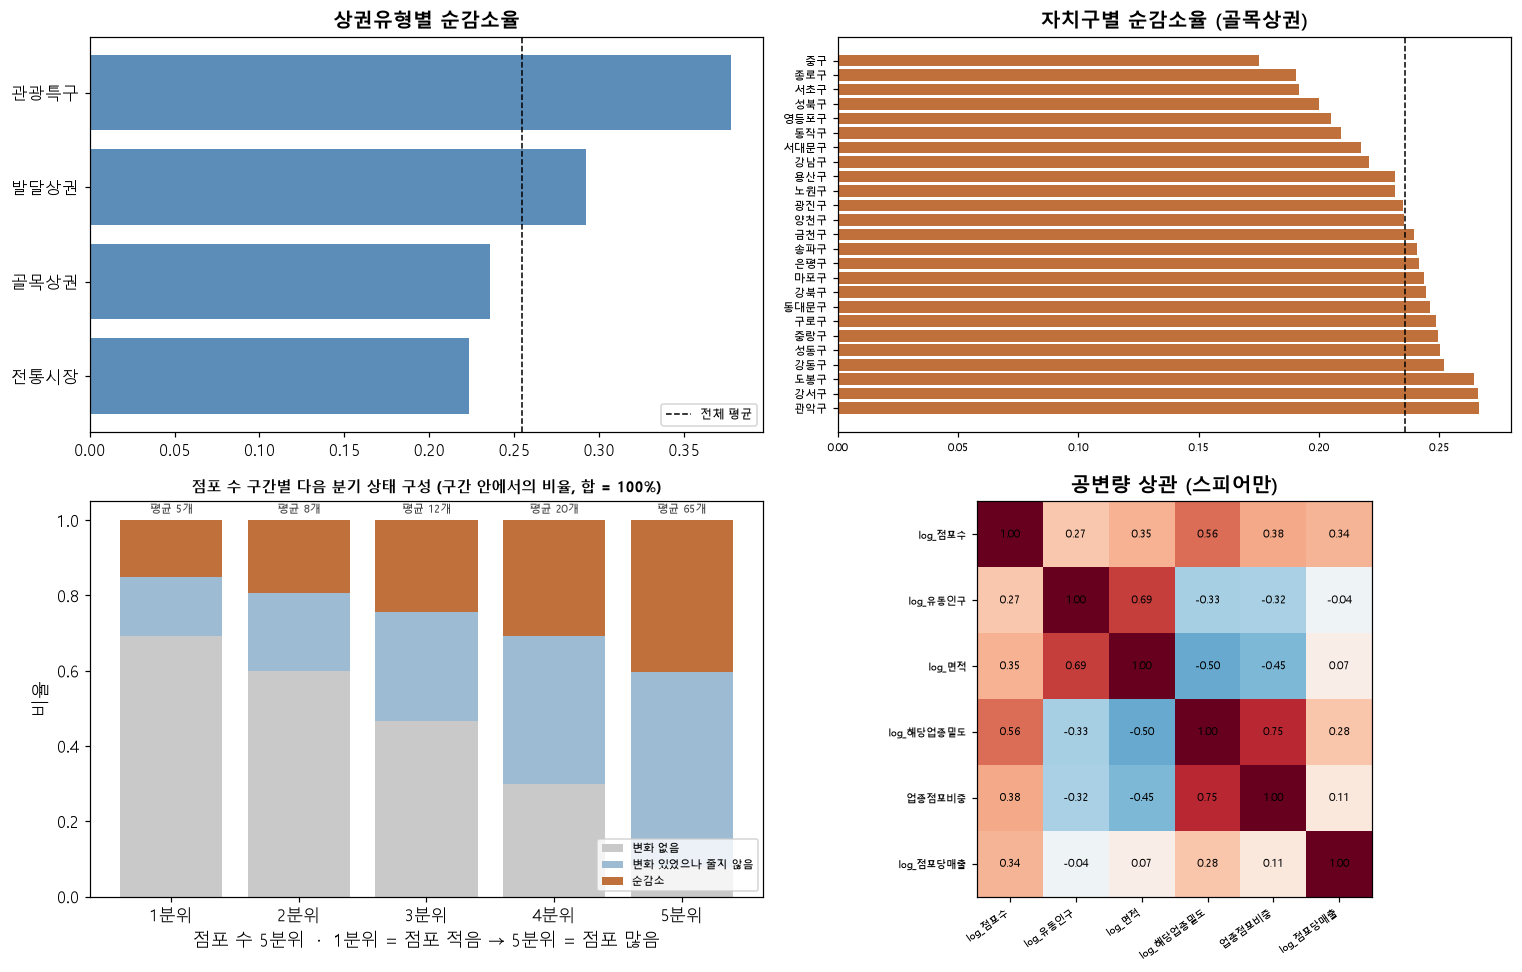

*그림 1*


상관이 큰 쌍 (스피어만)
  log_해당업종밀도       ~ 업종점포비중           +0.753
  log_유동인구         ~ log_면적           +0.692
  log_점포수          ~ log_해당업종밀도       +0.558
  log_면적           ~ log_해당업종밀도       -0.503

|r| > 0.8 인 쌍 0개

※ 0.6이라는 눈금에 규칙은 없음. 그리고 트리 계열 모형에서 상관은 «예측»을 망치지 않음.
  망치는 것은 «해석»임 — SHAP이 상관된 두 변수 사이에 기여를 쪼개 나눠 가져서
  각각의 중요도가 실제보다 낮게 보임. 다음 노트북에서 SHAP 순위를 읽을 때
  위 상위 쌍은 하나의 덩어리로 보아야 함.

### 읽는 법

검정 결과는 p-value와 효과크기를 함께 봐야 함. p-value는 «차이가 우연인가»만 답하고 «차이가 큰가»는 답하지 않음. 표본이 수만 건이면 아주 작은 차이도 p가 0에 가깝게 나옴. Cramér's V와 ε²가 그 크기를 재는 값이며, 0.1 미만이면 통계적으로 유의해도 실질적 차이는 작다고 해석함.

상관 행렬은 색이 진할수록 상관이 큼. 대각선은 자기 자신이므로 항상 1임. 네 장 중 왼쪽 아래 그림은 점포 수 5분위별로 다음 분기 상태 구성을 100% 누적 막대로 그린 것이며, 막대 하나의 높이가 그 구간 안에서의 비율 합 100%임.



### 해석

상권유형에 따라 순감소율이 다르다는 것은 확인되나 효과크기가 크지 않음. «유형이 위험을 만든다»고 말하기에는 부족하고, 유형 안에 섞여 있는 규모·업종 구성을 떼어내고 다시 봐야 함.

상관 행렬에서 절대값 0.8을 넘는 쌍은 없음. 다만 업종 밀도와 업종 점포 비중, 유동인구와 면적은 0.7 안팎으로 함께 움직임. 트리 계열 모형에서 이 상관은 예측을 망치지 않으나 해석을 흐림 — 뒤의 기여도 순위를 읽을 때 이 두 쌍은 각각 하나의 덩어리로 보아야 함.



## 5. 비교 기준 — 모델이 넘어야 하는 선

모델을 만들기 전에 «아무것도 안 하는 규칙»이 얼마나 맞히는지 먼저 재 둠. 이 값을 넘지 못하면 모델을 쓸 이유가 없음. 네 가지 기준을 세움 — 무작위, 직전 분기, 서울시 상권변화지표, 점포 수임.

«점포 수»를 반드시 넣어야 함. 큰 칸일수록 사건이 자주 일어나고 그만큼 순감소로 잡힐 확률도 높으므로, 점포 수 하나만 알아도 어느 정도는 맞힘. 이 기준을 세워 두지 않으면 모델의 성능이 «위험을 읽어낸 것»인지 «그냥 큰 칸을 고른 것»인지 구분할 수 없음.



,기준선,위험으로 찍은 수,정밀도,재현율,Lift
0,무작위(전부 위험),67475,0.255,1,1
1,직전 분기,15682,0.284,0.259,1.11
2,상권변화지표(HL),12608,0.244,0.179,0.956
3,"점포 수(상위 15,682칸)",15682,0.394,0.359,1.54


기저율 25.5% = 무작위로 찍을 때의 기대 정밀도이며, 이 값이 Lift 1.0의 기준임.
따라서 모델이 넘어야 하는 선은 기저율이 아니라 위 네 기준선 중 가장 높은 것임 —
  «점포 수(상위 15,682칸)»  정밀도 0.394 · Lift 1.545
이 값을 넘지 못하면, 그 규칙 하나로 대체할 수 있으므로 모델을 쓸 이유가 없음.

y,0,1
순감소_현재,,
0,39057,12736
1,11228,4454


chi2(1) = 92.1, p = 0, Cramer V = 0.037, 오즈비 = 1.22
-> p는 사실상 0이지만 V가 작으면 직전 분기만으로는 예측력이 약하다는 뜻임. p-value만 보고 결론을 내면 안 되는 이유의 실물임.

### 읽는 법

표의 각 행이 하나의 «아무것도 학습하지 않은 규칙»임. «무작위»는 전부 위험으로 찍는 경우이고, «직전 분기»는 이번 분기에 순감소였으면 다음 분기도 그럴 것으로 보는 규칙, «상권변화지표»는 서울시가 이미 쓰는 진단이 상권축소이면 위험으로 보는 규칙, «점포 수»는 점포가 많은 칸부터 차례로 위험으로 찍는 규칙임.

«정밀도»는 위험으로 찍은 칸 중 실제로 순감소였던 비율이고, «재현율»은 실제 순감소 칸 중 찾아낸 비율임. «Lift»는 정밀도를 기저율로 나눈 값이며 1.0이 무작위와 같음. 공정한 비교를 위해 «점포 수» 규칙이 찍는 개수를 «직전 분기»와 같게 맞춤.

표 아래 기저율은 무작위로 찍을 때의 기대 정밀도이며 Lift 1.0의 기준점임. 모델이 넘어야 하는 선은 기저율이 아니라 이 네 규칙 중 가장 높은 값임.



### 해석

가장 강한 기준은 «점포 수»임. 규칙 하나에 학습이 전혀 없는데도 정밀도가 기저율의 1.5배를 넘음. 이는 앞에서 본 «큰 칸일수록 사건이 자주 일어난다»는 성질이 그대로 반영된 결과임.

주목할 것은 서울시 공식 상권변화지표의 Lift가 1보다 낮다는 점임. 상권축소로 진단된 칸을 위험으로 찍는 것이 무작위로 찍는 것보다 못하다는 뜻이며, 그 지표가 «지금까지의 상태»를 요약할 뿐 «다음 분기»를 겨냥하지 않기 때문으로 보임.

따라서 모델의 성능은 «무작위보다 낫다»가 아니라 «점포 수 규칙보다 낫다»로 판정해야 함.



## 6. 점포 수를 고정하면 무엇이 남는가

전체 표본에서 잰 값에는 «규모가 큰 칸을 골라낸 몫»이 포함되어 있음. 그래서 점포 수 5분위 안에서 같은 기준을 다시 재 봄. 층 안에서는 칸의 크기가 서로 비슷하므로, 여기서도 값이 1을 넘으면 그 기준은 규모가 아닌 무언가를 읽고 있다고 말할 수 있음.



,칸수,평균점포,기저율,직전 분기 Lift,상권변화지표 Lift,점포 수 Lift
규모구간,,,,,,
1분위,15520,5.4,0.151,0.947,1.01,1.13
2분위,14018,7.9,0.193,0.963,1.05,1.15
3분위,12139,11.7,0.243,1,1.01,1.09
4분위,12718,19.6,0.308,0.955,1.06,1.1
5분위,13080,65.5,0.403,1.01,0.969,1.06


-> «점포 수» 의 층내 Lift가 1 근처로 내려가면, 전체 표본에서의 성능이
   상권의 위험을 읽은 것이 아니라 규모를 고른 결과였다는 뜻임.

,노출·사건,노출·비사건,비노출·사건,비노출·비사건,노출군 사건률,비노출군 사건률,층 오즈비
1분위,1618,8636,728,4538,0.1578,0.1382,1.17
2분위,1701,6817,1009,4491,0.1997,0.1835,1.11
3분위,1665,4934,1281,4259,0.2523,0.2312,1.12
4분위,1805,3862,2118,4933,0.3185,0.3004,1.09
5분위,1377,2232,3888,5583,0.3815,0.4105,0.8859


층을 통제하지 않은 단순 비교
  골목상권 0.2357 · 그 밖 0.2749 · 오즈비 0.813

Woolf 동질성 검정   Q = 27.387, p = 0.000016601529271  → 층별 오즈비가 서로 다름 (합쳐 말할 수 없음)
MH 공통 오즈비      1.061  95% CI [1.023, 1.101]  → 1을 포함하지 않음
CMH 검정            chi2(1) = 9.834, p = 0.0017  → 유의  (층 5개)

단순 오즈비와 공통 오즈비를 견주면 점포 수가 만든 교란의 크기가 보임.
두 값이 크게 다르면 단순 비교가 규모 차이를 읽고 있었다는 뜻임.

### 읽는 법

첫 표는 점포 수 5분위 구간별로 각 규칙을 다시 적용한 값임. 1분위가 점포 5~6개, 5분위가 27개 이상임. 구간 안에서는 칸의 크기가 서로 비슷하므로, 여기서 1을 넘으면 그 규칙이 «크기»가 아닌 무언가를 읽고 있다는 뜻임.

두 번째 표부터가 Cochran-Mantel-Haenszel 검정임. 층마다 «골목상권 여부 × 다음 분기 순감소»의 2×2 표를 만들고, 층별 오즈비를 함께 보임. 오즈비가 1보다 크면 골목상권이 더 위험하다는 뜻임.

읽는 순서가 정해져 있음. **먼저 Woolf 동질성 검정을 봄.** 층별 오즈비가 서로 같다고 볼 수 있어야 하나의 공통 오즈비로 요약할 수 있음. 동질성이 깨지면 공통 오즈비를 읽지 않고 층별 값을 그대로 보고해야 함.



### 해석

기저율이 구간에 따라 세 배 가까이 벌어짐. 이 격차 때문에 크기만으로 골라도 전체에서는 성적이 좋아 보임. 그런데 구간 안으로 들어가면 «점포 수» 규칙의 값이 1 근처로 내려앉고, 가장 작은 구간에서는 1보다 낮아짐 — 점포가 적은 상권들 사이에서는 크기가 아무 정보를 주지 못한다는 뜻임.

**CMH 검정에서 부호가 뒤집힘.** 층을 통제하지 않은 단순 비교에서는 골목상권이 더 안전해 보이나, 점포 수를 층으로 묶으면 오히려 더 위험한 쪽으로 바뀌고 그 차이가 통계적으로 유의함. 골목상권이 작은 상권에 몰려 있고 작은 상권은 사건 자체가 드물기 때문에, 통제하지 않으면 그 효과가 «골목상권이 안전하다»로 잘못 읽힘. Simpson의 역설이 실제로 나타난 것임.

**다만 층별 오즈비의 동질성이 성립하지 않음.** 작은·중간 구간에서는 골목상권이 더 위험하나 가장 큰 구간에서는 방향이 반대임. 따라서 «골목상권이 위험하다»를 하나의 숫자로 요약할 수 없고, 규모 구간을 나누어 말해야 함. 큰 골목상권이 사실상 다른 유형처럼 작동하는 것으로 보이는데, 그 이유는 이 분석으로 답하지 못함.

실무적으로 이것이 이 절의 핵심 교훈임. **단순 집계만으로 «어느 유형이 위험하다»고 말하면 방향이 반대로 나올 수 있음.** 규모를 통제하기 전의 비교는 근거로 쓸 수 없음.



## 7. 검정 방법의 선택 — 정규성과 등분산성

그룹 간 차이를 무엇으로 검정할지는 분포가 정함. 정규성과 등분산성이 성립하면 ANOVA, 아니면 비모수 검정을 씀. 순서를 거꾸로 하면 안 되므로 먼저 확인함.

라벨이 0/1 이진값이므로 그 자체에 Shapiro-Wilk를 걸면 의미가 없음. 이진 변수는 정의상 정규분포가 아니고 표본만 크면 p는 반드시 0으로 나옴. 그래서 검정 단위를 연속량으로 올림 — 상권 × 업종 칸마다 12분기의 순감소 비율을 계산하면 0~1 사이의 연속값이 되고, 이것이 그룹 간에 비교할 위험 수준의 자연스러운 단위임. 관측이 6분기 미만인 칸은 비율이 불안정하므로 제외함.

Levene 검정은 평균 대신 중앙값 기준으로 함. 분포가 치우쳐 있을 때 평균 기준 Levene은 그 자체로 왜곡됨.

검정만으로 끝내지 않고 Q-Q plot과 Boxplot을 함께 봄. Shapiro-Wilk는 «정규분포가 아니다»만 말하고 어떻게 아닌지는 말하지 않으므로, 꼬리가 긴 것인지 여러 봉우리인지에 따라 대응이 달라짐.



칸 단위 표본 5,687개 (관측 6분기 이상) · 제외 735개
순감소비율  평균 0.249 · 중앙값 0.250

,그룹 수,정규성 위배,정규성 성립 그룹,Levene 통계량,Levene p,등분산성
구분,,,,,,
상권유형,4,4/4,없음,16,0.000000000234641,위배
서비스_업종_코드_명,10,10/10,없음,10.83,0,위배
자치구,25,25/25,없음,1.45,0.0727,성립


→ 정규성이 성립하지 않는 그룹이 많으면 주 검정은 Kruskal-Wallis 로 감. ANOVA 는 참고로만 둠.

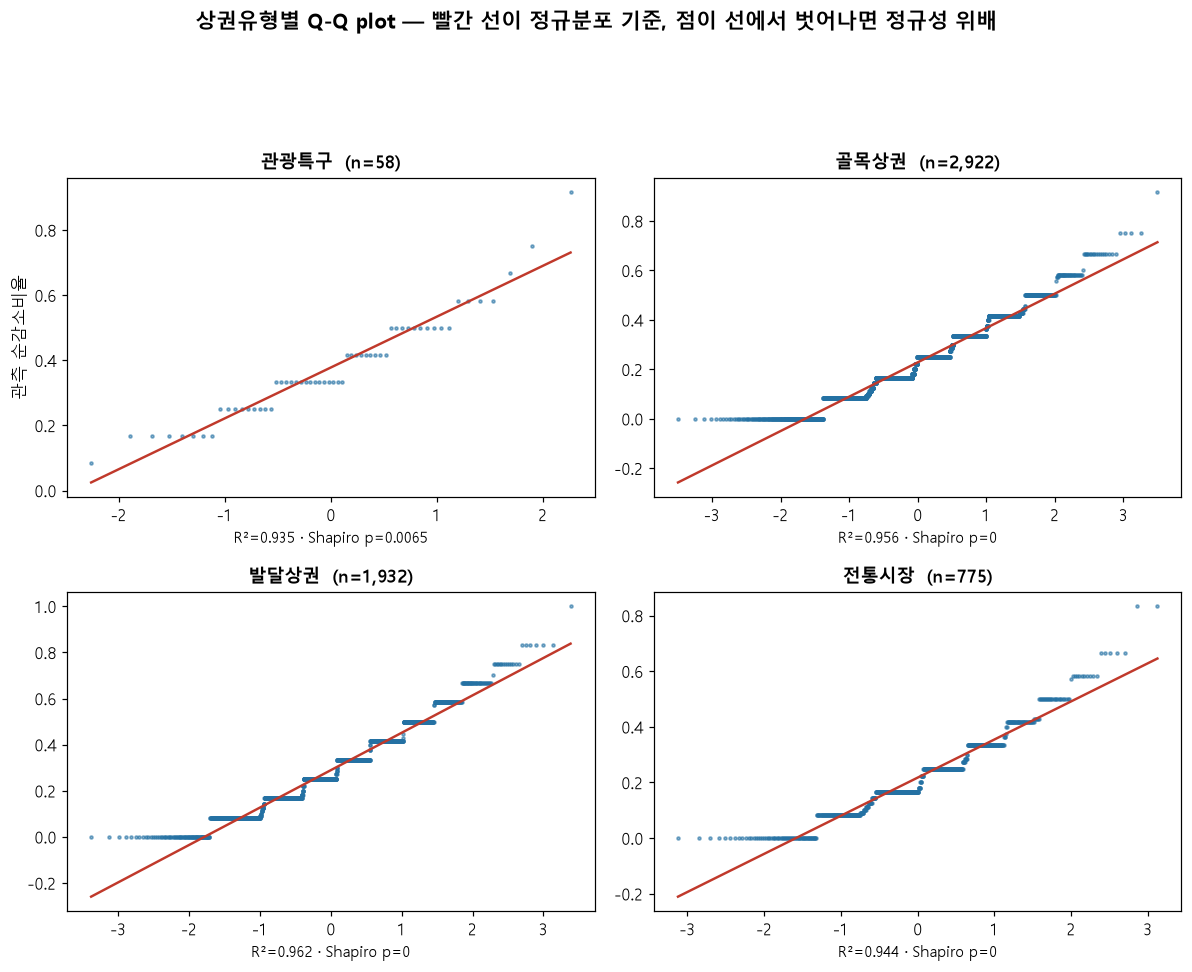

*그림 2*


→ 오른쪽 끝이 빨간 선 위로 휘면 오른쪽 꼬리가 긴 분포임.
  왼쪽 끝이 수평으로 눌린 계단은 «12분기 중 순감소 0회» 칸이 한 값에 쌓인 자리임.

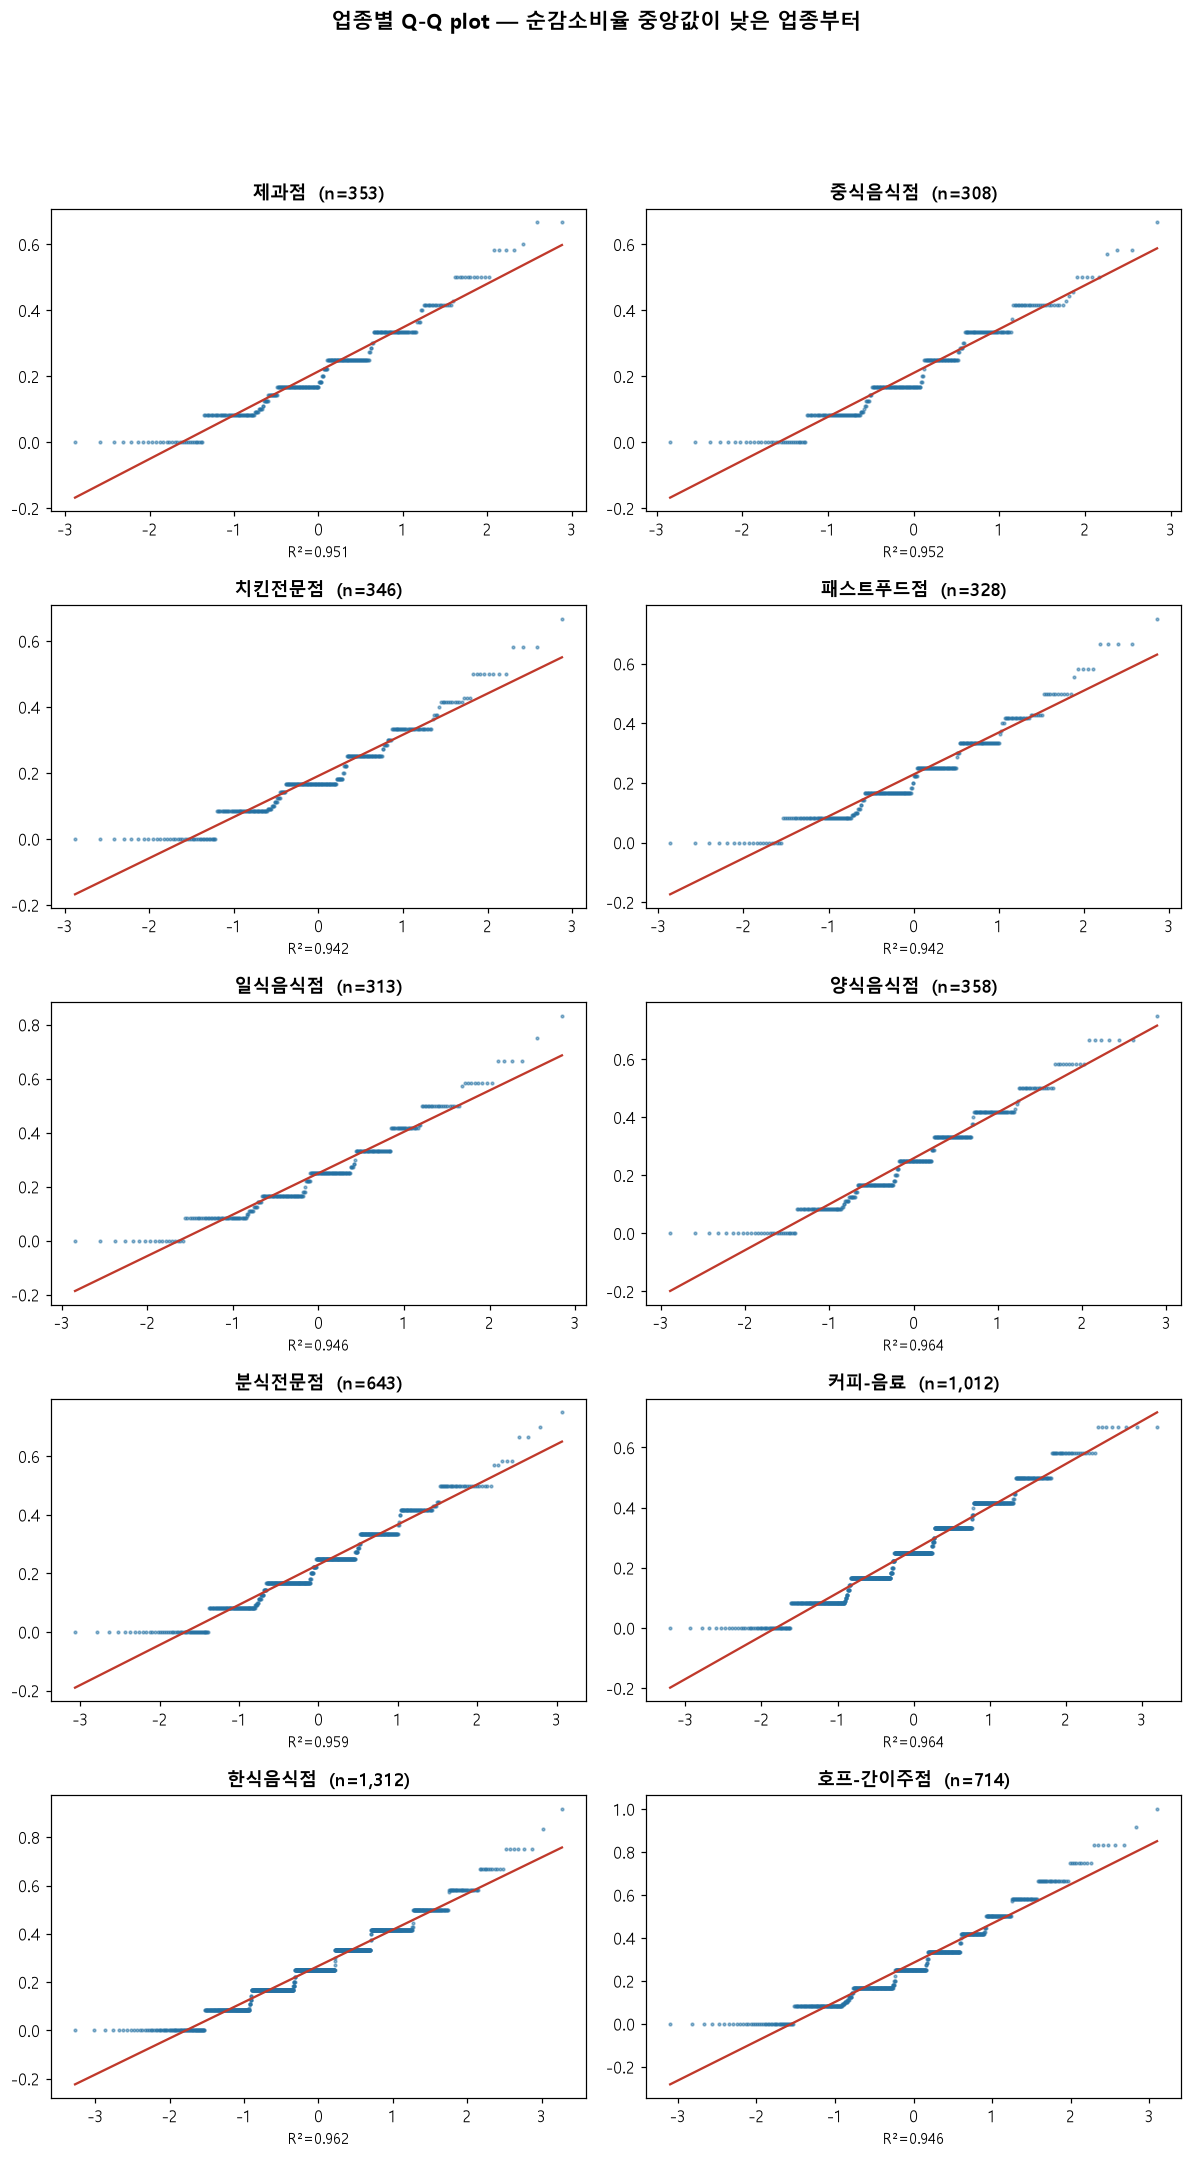

*그림 3*


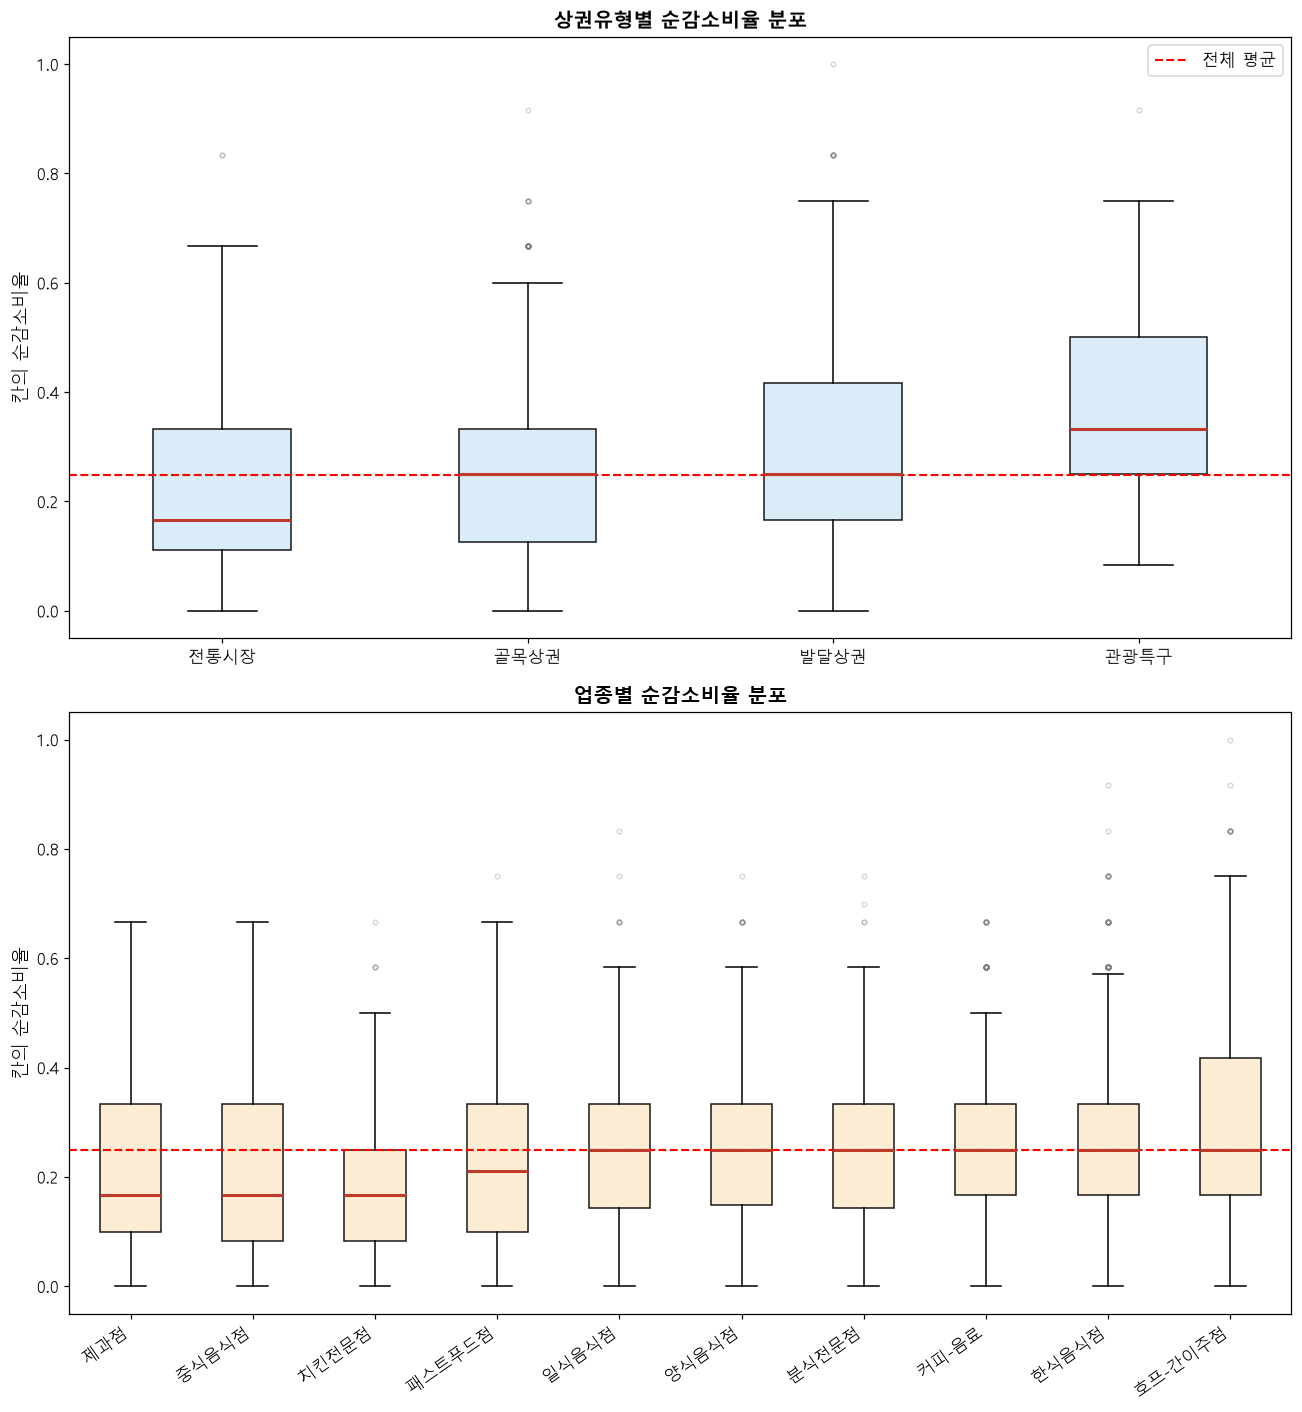

*그림 4*


전체 분포  왜도 0.5917 · 첨도 0.2881 · 순감소가 한 번도 없던 칸 7.1%
→ 왜도가 양수이고 0에 몰린 칸이 있으면 오른쪽 꼬리가 긴 분포임.
  Boxplot 에서 상자 높이가 그룹마다 다른 것이 등분산성 위배의 모습임.
  이 형태에서는 평균 비교(ANOVA)가 중앙값 비교(Kruskal-Wallis)보다 불리함.

### 읽는 법

표의 «정규성 위배»는 그룹 수 대비 Shapiro-Wilk 검정에서 정규성이 기각된 그룹의 수임. «Levene p»가 0.05보다 작으면 그룹 간 분산이 다르다고 보아 등분산성 위배로 판정함.

Q-Q plot은 그룹마다 패널을 따로 두었음. 가로축이 정규분포를 가정했을 때 기대되는 위치, 세로축이 실제 관측값임. 빨간 선이 정규분포 기준이고, 점이 그 선을 따라 놓이면 정규분포에 가까움. 패널 제목의 R²는 점이 선에 얼마나 붙어 있는지를 나타냄.

Boxplot에서 상자는 가운데 50%가 들어가는 구간, 상자 안의 선이 중앙값, 점은 이상치임. 상자의 높이가 그룹마다 다르면 그것이 등분산성 위배의 모습임.



### 해석

정규성은 사실상 모든 그룹에서 성립하지 않음. Q-Q plot에서 왼쪽 끝이 수평으로 눌린 계단이 나타나는데, 이는 «12분기 동안 순감소가 한 번도 없었던 칸»이 한 값에 쌓여 생기는 것임. 분포가 0 쪽에 몰리고 오른쪽으로 꼬리가 긴 형태이며 왜도가 양수인 것이 이를 뒷받침함.

등분산성은 갈림. 상권유형과 업종은 위배이나 자치구는 성립함. 자치구별로는 분포의 폭이 비슷하다는 뜻이며, 이는 뒤에서 자치구 간 차이가 작게 나오는 것과 같은 방향의 신호임.

이 형태에서는 평균을 비교하는 ANOVA가 불리함. 꼬리가 긴 분포에서 평균은 소수의 큰 값에 끌려가기 때문임. 따라서 주 검정은 순위를 쓰는 Kruskal-Wallis로 하고 ANOVA는 참고로만 둠.



## 8. 가설 직접 검증 — 업종 × 상권유형 · 업종 × 자치구

전체를 한 번에 검정하면 업종 구성이 섞여 들어감. 특정 유형에 특정 업종이 몰려 있으면 유형 효과와 업종 효과가 붙어 버림. 그래서 업종을 하나로 고정한 뒤 그 안에서 상권유형 간 차이를 봄. «동일 업종이라도 상권유형에 따라 다른가»를 문자 그대로 검정하는 형태임.

10개 업종에 같은 검정을 반복하므로 Bonferroni 보정을 적용함. 효과크기는 ε²로 내며 0.01 작음 / 0.06 중간 / 0.14 큼을 기준으로 함. 표본이 커서 p는 거의 항상 유의하므로 실제 판정은 효과크기가 함.

자치구 비교는 골목상권만 떼어 수행함. 유형을 고정해 유형 효과를 제거한 상태에서 입지 효과를 보기 위함임. 다만 이 조건에서는 표본이 20칸 이상인 업종이 소수로 줄어 검정력이 낮아지는 한계가 있음.



업종 × 상권유형 — 업종을 고정하고 유형 간 차이를 봄

,그룹수,H,n,p-value,유의,eps2
업종,,,,,,
호프-간이주점,3,86.9,709,0,True,0.1202
커피-음료,3,67.4,1006,0.000000000000002,True,0.0652
한식음식점,3,81,1306,0,True,0.0607
양식음식점,3,18.8,352,0.000081024701224,True,0.0483
분식전문점,3,32.5,637,0.000000088388986,True,0.0481
일식음식점,3,15.6,307,0.0004,True,0.0448
제과점,3,12.9,347,0.0015,True,0.0318
중식음식점,3,11,302,0.0041,True,0.03
패스트푸드점,3,7.1,322,0.0281,False,0.0161


Bonferroni α = 0.0050 · 유의 8/10개 · eps2 0.0002~0.1202

업종 × 자치구 (골목상권만 — 유형을 고정해 유형 효과를 제거함)

,그룹수,H,n,p-value,유의,eps2
업종,,,,,,
한식음식점,24,41.1,815,0.0116,False,0.0229
호프-간이주점,7,9.1,152,0.1679,False,0.0214
커피-음료,23,33.4,622,0.057,False,0.019


Bonferroni α = 0.0050 · 유의 0/3개 · eps2 0.0190~0.0229

평균 eps2   상권유형 0.0465 · 자치구 0.0211
→ 효과크기가 더 큰 쪽은 «상권유형». 위험이 «유형이라는 범주»보다
  «구체적 입지»에 더 좌우되는지를 이 비교가 판정함.

### 읽는 법

각 행이 하나의 업종임. 그 업종 안에서만 상권유형(또는 자치구) 간 순감소 수준을 비교한 결과이므로, «동일 업종이라도 장소에 따라 다른가»에 대한 답임.

«유의» 열은 Bonferroni 보정을 통과했는지임. 같은 검정을 열 번 반복하면 우연히 유의해지는 경우가 생기므로 기준을 열 배 엄격하게 한 것임. «eps2»가 효과크기이며 0.01 작음 / 0.06 중간 / 0.14 큼으로 읽음.

표는 효과크기가 큰 업종부터 정렬했음. p-value가 아니라 효과크기 순으로 읽어야 «어느 업종이 장소에 민감한가»가 보임.



### 해석

상권유형 쪽에서는 대부분의 업종이 유의하게 갈림. 다만 효과크기는 업종마다 크게 다름. 호프-간이주점이 가장 크고 커피-음료와 한식음식점이 그 다음임. 반면 치킨전문점은 효과크기가 거의 0이며 유의하지도 않음 — 이 업종은 어디에 있든 위험 수준이 비슷하다는 뜻이고, 배달 비중이 높아 입지 의존이 낮은 업태의 성질로 보임.

자치구 쪽은 유의한 업종이 나오지 않음. 이는 «자치구가 상관없다»는 결론으로 바로 이어지지 않음. 골목상권만 떼어 유형 효과를 제거한 상태이고, 그 조건에서 표본이 20칸 이상 남는 업종이 소수로 줄어 검정력이 크게 떨어지기 때문임. 이 한계를 안고 읽어야 함.

두 비교의 평균 효과크기를 견주면 상권유형 쪽이 큼. 즉 이 데이터에서는 «어느 자치구인가»보다 «어떤 유형의 상권인가»가 위험을 더 갈라 놓음.



## 9. 성향점수매칭 — 조건을 맞추고 다시 비교

업종 간 단순 비교에서는 공변량이 심각한 불균형 상태임. 그 상태의 격차는 «업종 차이»가 아니라 «규모 차이»를 읽은 것일 수 있음. «불균형이라 비교가 성립하지 않는다»에서 멈추면 질문에 답을 못 한 것이므로, 규모·유동인구·면적·집객시설이 비슷한 칸끼리 짝을 지어 다시 비교함.

처리군은 한식음식점으로 하며, 순감소율을 보기 전에 미리 고정함. 표본이 가장 크고 골목상권을 대표하는 업종이라는 선험적 근거로 정한 것임. 순감소율이 가장 높은 업종을 고른 뒤 그 격차를 검정하면 선택 효과가 섞여 들어감 — 10개 중 최고를 고르는 행위 자체가 위쪽 꼬리를 뽑기 때문에 차이가 없어도 «최고»는 전체 평균보다 높게 나옴.

매칭은 성향점수의 로짓 거리로 1:1 최근접 이웃을 찾되, 분기를 정확히 일치시키고 비복원으로 함. 분기마다 전체 위험 수준이 다르므로 다른 분기의 칸과 짝지으면 시점 효과가 업종 효과로 잘못 읽힘. 같은 대조군 칸을 여러 번 쓰면 그 칸의 우연한 값이 결과를 반복해서 밀어 올림. 캘리퍼를 두어 너무 먼 짝은 배제하고, 짝을 찾지 못한 처리군의 개수를 기록함.

매칭을 했다고 균형이 맞는 것이 아니므로 매칭 전후 SMD를 나란히 놓고 모두 0.1 아래로 내려왔는지 확인함. 내려오지 않으면 그 뒤의 수치는 읽을 값이 아님.



처리군 한식음식점 9,957칸 · 대조군 24,690칸
성향점수 0.0041~0.9995 · 캘리퍼 0.3455 (logit 표준편차의 0.2배)
공통지지영역 0.0107~0.9990 · 그 안의 처리군 100.0% · 대조군 97.7%


매칭 6,836쌍 · 처리군 매칭률 68.7% · 짝을 못 찾아 제외 3,121개

,매칭 전 SMD,매칭 후 SMD,감소폭,판정
공변량,,,,
log_점포수,0.999,0.026,0.973,균형
log_유동인구,-0.447,0.041,0.405,균형
log_면적,-0.473,0.031,0.442,균형
log_집객시설,-0.406,0.006,0.4,균형
logit_ps,1.55,-0.002,1.55,균형


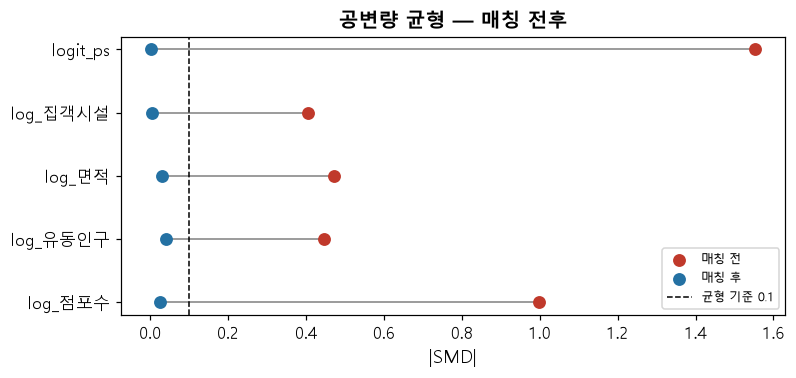

*그림 5*


모든 공변량 |SMD| < 0.1 : 예 — 비교 조건이 맞았으므로 아래 ATT를 읽을 수 있음

매칭 전 단순 격차   0.2527 − 0.2288 = +0.0238  (+2.38%p)
매칭 후 ATT        0.2298 − 0.2844 = -0.0546  (-5.46%p)

McNemar  불일치 쌍 2,613개 (처리군만 순감소 1,120 · 대조군만 순감소 1,493)
         p = 0.000000000000311  → 유의
         일치 쌍 4,223개는 검정에 쓰이지 않음

클러스터 부트스트랩 95% CI  [-6.77%p, -3.81%p]  (상권 866개 · 500회)
0을 포함하는가: 아니오 — 방향이 일관됨

→ 단순 격차와 ATT의 **부호가 뒤집혔음.** 단순 비교에서 보였던 격차는 업종 차이가 아니라
  규모·입지 차이(교란)를 읽은 것이었다는 뜻임. 5-4의 «심각한 불균형»이 이 결과의 원인임.

,쌍/칸 수,ATT(%p)
설계,,
매칭 없음(단순 격차),34647,2.38
캘리퍼 0.1×SD,6836,-5.59
캘리퍼 0.2×SD,6836,-5.46
캘리퍼 0.3×SD,6838,-5.47
캘리퍼 0.5×SD,6841,-5.47
복원 허용,9943,-4.43


매칭 설계 5종의 ATT 범위 -5.59 ~ -4.43%p
부호 일치: 예 — 방향은 설계의 산물이 아님
매칭 없음과의 차이: +2.38%p → -5.28%p (매칭 평균)

### 읽는 법

첫 표가 매칭의 핵심임. «매칭 전 SMD»는 처리군과 대조군이 원래 얼마나 달랐는지, «매칭 후 SMD»는 짝을 지은 뒤 얼마나 비슷해졌는지를 나타냄. 절대값 0.1이 기준선이며 그 아래로 내려와야 «조건이 맞았다»고 말할 수 있음. 그림은 같은 값을 점으로 옮긴 것이며, 빨간 점에서 파란 점으로 왼쪽으로 이동한 거리가 매칭이 해낸 몫임.

ATT는 짝지은 쌍에서 «처리군 순감소율 − 대조군 순감소율»임. 음수면 처리군이 더 안전하다는 뜻임. McNemar 검정은 두 값이 서로 다른 쌍만 세는 방식이며, 같은 쌍은 어느 쪽이 위험한지에 대해 정보를 주지 않으므로 계산에서 빠짐.

신뢰구간은 상권을 단위로 다시 뽑아 계산했음. 같은 상권의 여러 업종 칸은 서로 독립이 아니므로 칸을 개별로 뽑으면 구간이 실제보다 좁게 나옴. 구간이 0을 포함하지 않으면 방향을 말할 수 있음.

마지막 표는 설계를 바꿔 본 결과임. 캘리퍼 폭과 복원 여부를 달리해도 부호가 유지되는지 확인하는 것이며, «매칭 없음» 행이 비교 기준임.



### 해석

매칭 전에는 처리군과 대조군의 점포 수 차이가 매우 컸음. 즉 이 두 집단은 애초에 비교할 수 있는 상태가 아니었고, 그 상태에서 잰 격차는 업종 차이가 아니라 규모 차이를 읽은 것이었음.

매칭 후 모든 공변량이 균형 기준 아래로 내려옴. 조건이 맞았으므로 이제 격차를 업종 효과로 읽을 수 있음.

그 결과는 방향이 뒤집힘. 매칭 전에는 처리군이 더 위험해 보였으나, 조건을 맞추자 오히려 더 안전한 쪽으로 바뀜. 검정과 신뢰구간, 설계를 바꾼 다섯 가지 경우가 모두 같은 방향을 가리킴.

이것이 보조 질문에 대한 답임. 특정 업종이 위험해 보였던 것은 그 업종의 성질이 아니라 그 업종이 큰 상권에 몰려 있다는 사실 때문이었음. 크기와 입지를 맞추면 결론이 반대가 됨. 단순 집계만으로 업종 위험을 말하면 안 되는 이유를 이 절이 수치로 보여 줌.



## 10. 사후검정 — 어느 쌍이 다른가

Kruskal-Wallis는 «어딘가 차이가 있다»까지만 말함. 그룹이 넷이면 가능한 쌍이 여섯인데 그중 어느 쌍이 다른지는 알려주지 않음. Dunn's test는 Kruskal-Wallis와 같은 순위를 그대로 써서 쌍마다 z를 내므로 앞선 검정 결과와 정합적임. 쌍의 개수만큼 Bonferroni 보정함.

동순위 보정을 적용함. 순감소 비율은 0, 1/12, 2/12 같은 값이 반복되어 동순위가 많고, 보정 없이 계산하면 분산이 과대추정되어 유의성이 실제보다 낮게 나옴.

표에는 p-value와 함께 어느 쪽이 높은지를 담음. p만 있으면 방향을 알 수 없기 때문임. 자치구는 쌍이 300개이므로 표 대신 유의성 히트맵과 자치구별 유의 쌍 개수로 정리함.



상권유형 — 순위 중앙값 낮은 순으로 정렬

,median,mean,size
상권유형,,,
전통시장,0.1667,0.2176,775
골목상권,0.25,0.2282,2922
발달상권,0.25,0.2894,1932
관광특구,0.3333,0.3779,58


,전통시장,골목상권,발달상권,관광특구
전통시장,1,0.321,0,0
골목상권,0.321,1,0,0
발달상권,0,0,1,0.0003
관광특구,0,0,0.0003,1


,z,p(보정),유의,더 높은 쪽
쌍,,,,
전통시장 ↔ 발달상권,10.41,0,True,발달상권
전통시장 ↔ 관광특구,7.23,0,True,관광특구
골목상권 ↔ 발달상권,12.44,0,True,발달상권
골목상권 ↔ 관광특구,6.84,0,True,관광특구
발달상권 ↔ 관광특구,4.07,0.0003,True,관광특구
전통시장 ↔ 골목상권,1.93,0.321,False,골목상권


유의한 쌍 5/6개 (Bonferroni 보정 후 α=0.05)

골목상권 안에서 자치구 25개 · 가능한 쌍 300개 · 유의한 쌍 3개 (1.0%)
  순감소 수준이 낮은 편 : 서초구, 동작구, 양천구, 종로구, 중구
  순감소 수준이 높은 편 : 노원구, 관악구, 송파구, 은평구, 중랑구

→ 유의한 쌍의 비율이 매우 낮음. 자치구 대부분이 서로 구분되지 않는 중간군을 이룸.
  자치구를 범주로 묶어도 그 안에서 얻을 정보가 적다는 뜻이며,
  이 분석의 단위를 상권 × 업종으로 잡은 판단을 뒷받침함.
  같은 자치구 안에서도 상권마다 사정이 다르므로 행정 경계로 대응하면 위험한 곳을 놓침.

### 읽는 법

첫 표는 그룹별 중앙값과 평균이며 중앙값이 낮은 순으로 정렬했음. 두 번째 표가 쌍별 p-value 행렬이고, 세 번째 표가 같은 내용을 쌍 목록으로 펼친 것임. «z»의 부호가 방향을 나타내고 «더 높은 쪽» 열이 그것을 이름으로 적은 것임. p-value는 쌍의 개수만큼 보정된 값임.

자치구 그림에서 왼쪽은 쌍별 유의성 지도임. 붉은 칸이 두 자치구가 유의하게 다른 쌍이고, 축은 중앙값이 낮은 순으로 정렬되어 있음. 오른쪽 막대는 자치구별 수준이며 괄호 안 숫자가 그 자치구가 다른 구와 유의하게 갈린 쌍의 개수임.



### 해석

상권유형은 대부분의 쌍이 서로 구분됨. 다만 전통시장과 골목상권은 유의하게 갈리지 않음. 두 유형이 위험 수준에서 비슷한 자리에 있다는 뜻이며, 정책상 하나의 묶음으로 다루어도 무리가 없다는 근거가 됨.

관광특구가 가장 높고 발달상권이 그 다음임. 사람이 많이 모이는 상권일수록 회전이 빠르고 그만큼 빠져나가는 점포도 많다는 해석과 맞음.

자치구는 사정이 다름. 가능한 쌍 중 유의한 쌍이 극히 적음. 낮은 쪽과 높은 쪽 몇 개를 빼면 대부분의 자치구가 서로 구분되지 않는 중간군을 이룸. 자치구를 범주로 넣어도 그 안에서 얻을 정보가 적다는 뜻이고, 앞 절에서 자치구 효과크기가 작게 나온 것과 일관됨.

따라서 위험을 말할 단위는 자치구가 아니라 상권임. 같은 자치구 안에서도 상권마다 사정이 다르므로, 행정 경계로 묶어 대응하면 정작 위험한 곳을 놓치게 됨.



## 11. 모델 선정

성격이 다른 다섯 계열을 같은 검증 분기에서 비교함 — 단일 트리, 배깅 앙상블, 선형 확률모형, 마진 기반 분류기, 부스팅임. 불균형은 모든 모델에 가중치로 다뤄 조건을 같게 맞춤.

분할 이전에 오버샘플링을 하지 않음. 복제된 소수 클래스가 학습과 검증에 함께 들어가 성능이 부풀려지기 때문임. 가중치는 그 위험이 없음.

주지표는 AP(Average Precision)이며 정밀도-재현율 곡선 아래 면적임. 양성률이 26% 정도인 소수 사건이라 정확도는 판단 근거가 되지 못함 — 전부 0으로 찍기만 해도 74.7%가 나옴.

채택 모델은 XGBoost임. AP 1위가 아니지만 다섯 모델의 차이가 0.02 미만이어서 모델 선택이 결론을 바꾸지 않고, 트리 구조를 따라 기여를 정확히 분해하는 도구가 있는 유일한 축이기 때문임. 후반부 질문이 «무엇이 위험을 만드는가»이므로 분해 도구가 필요함.



양성 가중치 scale_pos_weight = 2.930

  [완료] 의사결정나무

  [완료] 랜덤포레스트

  [완료] 로지스틱 회귀

  [완료] 선형 SVM

  [완료] XGBoost

,AP,ROC-AUC,F1,정밀도,재현율,정확도,Lift
모델,,,,,,,
랜덤포레스트,0.408,0.676,0.401,0.401,0.401,0.697,1.584
선형 SVM,0.406,0.675,0.418,0.418,0.418,0.705,1.652
로지스틱 회귀,0.406,0.675,0.417,0.417,0.417,0.705,1.646
의사결정나무,0.398,0.667,0.420,0.401,0.441,0.692,1.585
XGBoost,0.398,0.665,0.405,0.405,0.405,0.699,1.601


검증 AP 1위 = 랜덤포레스트 (0.408)
채택 모델      = XGBoost (0.398)
→ XGBoost는 이 표에서 1위가 아님 (차이 +0.010). 7장 최종 평가에서 랜덤포레스트와 나란히 보고함.
참고: 전부 0으로 찍어도 정확도는 74.7% 임 — 정확도로 고르면 안 되는 이유

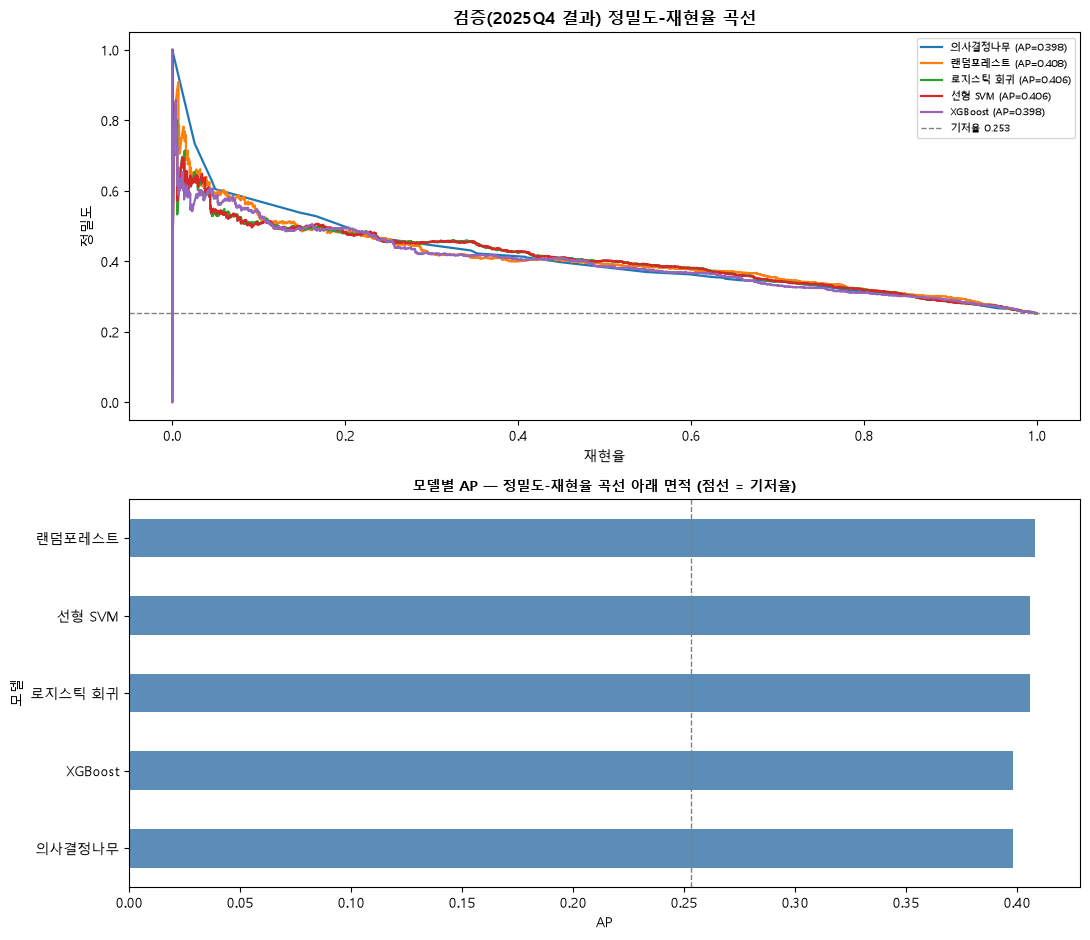

*그림 6*


## 12. 작동점 — 몇 칸을 위험으로 찍을 것인가

기저율과 같은 비율을 위험으로 찍는 설정은 조기경보의 실제 운영과 맞지 않음. 전체의 20%가 넘는 칸에 경보를 울리는 운영은 없고, 손이 닿는 수십~수백 곳을 찍음.

작동점은 검증 분기에서 고름. 테스트 결과를 본 뒤 «잘 나오는 지점»을 고르면 그 순간 테스트가 검증이 되어 버림. 검증에서 정한 값을 테스트에 그대로 옮겨 쓰고, 테스트 표의 다른 작동점은 참고로만 함께 보임.



,검증 정밀도,검증 재현율,검증 ÷ 기저율
위험으로 찍은 수,,,
50,0.580,0.021,2.292
100,0.600,0.043,2.371
200,0.555,0.080,2.193
300,0.513,0.111,2.028
500,0.488,0.175,1.928
800,0.448,0.257,1.768
1285,0.412,0.380,1.627
2000,0.378,0.543,1.494


검증 분기에서 정밀도가 가장 높은 작동점 = 상위 100칸
이 값을 테스트에 그대로 옮겨 씀

,XGBoost 정밀도,점포 수 정밀도,XGBoost 재현율,점포 수 재현율,XGBoost ÷ 기저율,점포 수 ÷ 기저율,두 목록 겹침,XGBoost 평균점포
위험으로 찍은 수,,,,,,,,
50,0.720,0.380,0.025,0.013,2.772,1.463,0.100,108.620
100,0.600,0.460,0.042,0.032,2.310,1.771,0.230,100.980
200,0.575,0.520,0.081,0.073,2.214,2.002,0.360,82.425
300,0.533,0.493,0.112,0.104,2.054,1.899,0.413,74.143
500,0.494,0.464,0.174,0.163,1.902,1.787,0.516,65.012
800,0.441,0.459,0.248,0.258,1.699,1.766,0.619,57.014
1285,0.398,0.427,0.359,0.386,1.531,1.645,0.687,47.151
2000,0.376,0.383,0.528,0.538,1.448,1.475,0.742,38.217


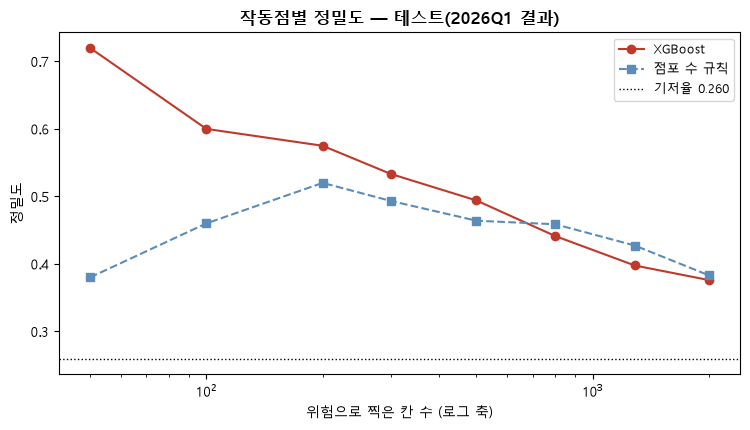

*그림 7*


검증에서 고른 작동점 — 상위 100칸에서의 테스트 성능
  모델 정밀도     0.600  (기저율의 2.31배)
  점포 수 정밀도   0.460  (기저율의 1.77배)
  두 목록 겹침     23%

모델 정밀도가 더 높은 작동점: [50, 100, 200, 300, 500]
  상위 50칸  모델 0.720 · 점포 수 0.380 (기저율의 2.77배)
  두 목록 겹침 10% — 서로 다른 상권을 지목함

참고 — 상위 100칸을 찍으면 실제 순감소 1,423칸 중 4.2% 만 포착함.
      정밀도가 높은 작동점은 그만큼 놓치는 양도 많으므로, 운영에서 볼 수 있는
      개수를 정한 뒤 그 지점의 두 값을 함께 보고해야 함.

→ 상위 소수를 찍는 작동점에서는 모델 정밀도가 더 높고,
  많이 찍을수록 «점포 수» 규칙과 값이 가까워짐.
  많이 찍으면 결국 큰 상권을 다 담게 되어 두 방법이 같아지기 때문임.
  즉 «전체 값이 낮다»는 것은 한 작동점의 성질이지 모델 전체의 성질이 아님.

,자치구,상권_코드_명,상권유형,서비스_업종_코드_명,전체_점포_수,개업_점포_수,폐업_점포_수,위험점수,y
1,강서구,발산역(마곡),발달상권,호프-간이주점,108.0,1.0,6.0,0.951,1
2,마포구,연남동(홍대),발달상권,호프-간이주점,149.0,4.0,14.0,0.947,1
3,광진구,건대입구역(건대),발달상권,호프-간이주점,145.0,6.0,4.0,0.939,0
4,강서구,강서구청,발달상권,호프-간이주점,84.0,3.0,3.0,0.935,1
5,강남구,압구정로데오역(압구정로데오),발달상권,호프-간이주점,88.0,3.0,13.0,0.922,1
6,강서구,발산역(마곡),발달상권,커피-음료,143.0,7.0,9.0,0.918,0
7,마포구,연남동(홍대),발달상권,커피-음료,215.0,6.0,6.0,0.914,1
8,강북구,수유역,발달상권,호프-간이주점,135.0,1.0,9.0,0.914,1
9,마포구,홍대입구역(홍대),발달상권,호프-간이주점,270.0,7.0,21.0,0.905,1
10,용산구,이태원(이태원역),발달상권,호프-간이주점,142.0,5.0,13.0,0.901,1


골목상권 2,772칸 중 위험 판정 496칸 (17.9%) · 실제 순감소율 23.1%
위험 판정 칸의 실제 순감소율 32.9% vs 미판정 21.0%

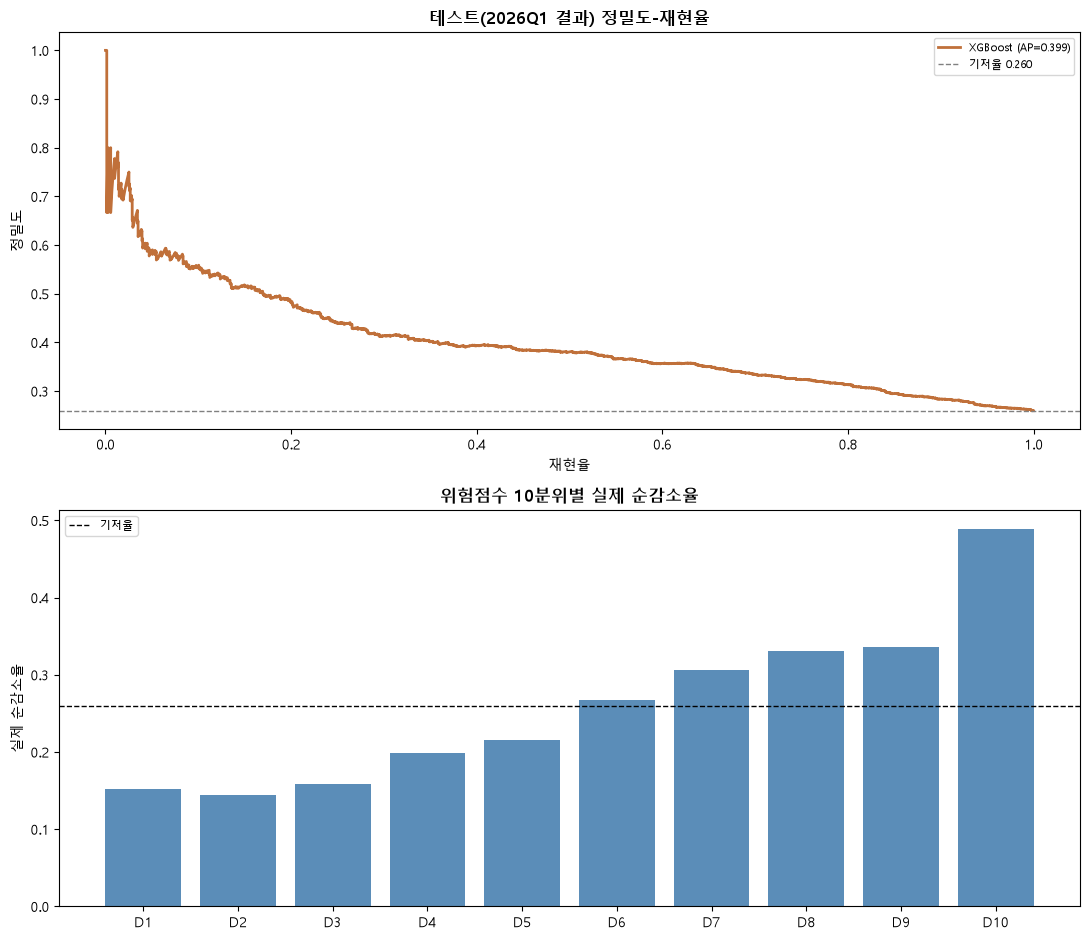

*그림 8*


→ 오른쪽이 단조 증가하면 점수가 위험 순서를 제대로 매기고 있다는 뜻임

## 13. 테스트 최종 평가 — 2026Q1 결과

학습 2023Q1~2025Q2, 검증 2025Q3, 테스트 2025Q4로 시간 순서대로 나누고 섞지 않음. 각 분기는 그 다음 분기의 결과로 채점함.

검증과 테스트는 역할이 다름. 검증은 모델을 고르고 임계값을 정하는 데 쓰므로 그 점수는 낙관적으로 치우침. 테스트는 결정이 끝난 뒤 한 번만 보므로 치우치지 않음. 임계값은 검증 분기에서 정한 것을 그대로 옮겨 씀.

2025년 4분기는 미래가 아니라 이미 지난 분기이므로 엄밀히는 홀드아웃임. 학습과 모델 선택에 일절 쓰지 않았다는 의미에서 테스트라고 부름.



,테스트(2026Q1 결과)
AP,0.399
ROC-AUC,0.648
정밀도,0.395
재현율,0.372
F1,0.384
정확도,0.689
Lift,1.522


      예측 0  예측 1
실제 0  3245   811
실제 1   893   530

기저율 26.0% · 위험으로 찍은 칸 1,341개

기준선 대비
  무작위(전부 위험)             Lift 1.000
  직전 분기                  Lift 1.199
  상권변화지표(HL)             Lift 0.937
  점포 수(상위 1,285칸)        Lift 1.645
  XGBoost                Lift 1.522

## 14. 두 단계로 나눈 모형

라벨은 두 개의 다른 일이 겹친 사건임. 하나는 다음 분기에 개·폐업이 한 건이라도 일어나는가이고, 다른 하나는 일어났다면 그것이 줄어드는 쪽인가임. 이를 두 모형으로 나누어 각각 추정하고 곱함.

곱하는 것은 근사가 아니라 정확한 등식임. 순감소는 반드시 사건의 부분집합이므로 — 폐업이 개업보다 많으면 폐업이 최소 한 건 있음 — 사건이 없는 경우의 순감소 확률이 정확히 0으로 사라짐.

나누는 실익은 규모 편향의 분리임. 앞에서 본 «작은 상권은 위험해서가 아니라 작아서 아무 일도 일어나지 않는다»는 문제가 1단계에 갇힘. 2단계는 이미 일이 일어난 칸만 보므로 그 편향이 원리적으로 들어올 수 없음.



분해가 정확한 등식인지
  P(사건)                0.5608
  P(순감소 | 사건)         0.4543
  곱                     0.2548
  P(순감소) 실제           0.2548   ← 곱과 같아야 함
  P(순감소 | 사건 없음)     0.0000  (해당 칸 중 y=1 이 0건)

두 단계가 규모와 맺는 관계 (스피어만)
  사건 여부    ~ log_점포수  +0.448
  순감소 | 사건 ~ log_점포수  -0.039

→ 규모 의존이 1단계에 거의 전부 몰려 있고, 2단계는 규모와 거의 무관함.
  이것이 «나누면 좋은 이유»의 실물임 — 2단계가 규모 편향 없는 위험 판단이 됨.

,AP,ROC-AUC,정밀도,재현율,Lift
방법,,,,,
단일 모형 (XGBoost),0.398,0.665,0.405,0.405,1.601
2단계 모형,0.405,0.673,0.421,0.421,1.663


1단계 P(사건) 검증 AP 0.810  (사건 발생률 52.2%)

검증 AP가 더 높은 쪽 = 2단계 모형 (차이 +0.007)

이후 장(해석·지도)은 «단일 모형»으로 진행함. 이유는 성능이 아니라 분해 가능성임 —
2단계 모형의 최종 점수는 두 모형의 «곱»이라 SHAP처럼 기여를 더해 분해할 수 없음.
따라서 2단계 모형은 «단일 모형이 규모 편향에 끌려간 것이 아닌지» 확인하는
강건성 점검으로 보고하고, 7장에서 테스트 성능을 나란히 제시함.

## 15. 두 확률로 나눈 상권 유형

두 확률은 서로 다른 것을 재기 때문에, 곱해서 하나로 합치지 않고 두 축으로 두면 상권의 성격이 갈림. 사건 확률이 «얼마나 활발하게 변하는가»를, 순감소 조건부 확률이 «변할 때 어느 방향인가»를 나타냄.

네 유형은 다음과 같음. 사건 확률과 조건부 확률이 모두 높으면 «활발하게 변하면서 쇠퇴하는 상권», 사건 확률은 높고 조건부 확률이 낮으면 «활발하게 변하지만 성장·유지되는 상권», 사건 확률은 낮고 조건부 확률이 높으면 «정체되어 있지만 변화가 생기면 취약한 상권», 둘 다 낮으면 «안정적인 상권»임.

이 구분이 필요한 이유는, 최종 위험도(두 확률의 곱)로 줄 세우면 사건 확률이 높은 쪽 — 즉 점포가 많은 상권이 앞으로 오고 작은 상권은 뒤로 밀리기 때문임. 그런데 뒤로 밀리는 쪽에 «조용하지만 한 번 흔들리면 버티지 못하는» 유형이 들어 있음. 순위 하나로 합치면 그 구분이 사라짐.

경계는 검증 분기의 중앙값으로 정함. 테스트 분기의 분포를 보고 자르면 그 순간 테스트가 검증이 됨. 두 축의 이름이 데이터와 맞는지는 다음 분기 실측으로 검산함 — 사건 축은 사건의 실제 발생률로, 방향 축은 사건이 난 칸만 골라 본 순감소 비율로 확인함. 분모를 «사건이 난 칸»으로 제한해야 조건부 확률의 검산이 됨.



검증 분기 중앙값으로 정한 경계  사건확률 0.4259 · 순감소조건부확률 0.5045

표 63

테스트 분기 기저율 0.260

,사건_수준,방향_수준,유형,칸수,사건_실제발생률,사건있던칸,순감소_조건부실제,전체_순감소율
0,낮음,낮음,안정적,1229,0.343,422,0.483,0.166
1,낮음,높음,정체되어 있으나 변화 시 취약,1535,0.333,511,0.577,0.192
2,높음,낮음,활발하게 변하나 성장·유지,1529,0.733,1120,0.436,0.319
3,높음,높음,활발하게 변하면서 쇠퇴,1186,0.677,803,0.543,0.368


검산
  사건 실제발생률      사건확률 높음 0.705 vs 낮음 0.338  → 이름과 일치
  순감소 조건부 실제    방향 높음 0.560 vs 낮음 0.460  → 이름과 일치

참고 — 현재 분기 개업·폐업 (라벨과 시점이 다르므로 검산에는 쓰지 않음)

,유형,평균개업,평균폐업,개폐업합,개업-폐업
0,안정적,0.14,0.35,0.48,-0.21
1,정체되어 있으나 변화 시 취약,0.26,0.16,0.43,0.10
2,활발하게 변하나 성장·유지,1.11,1.44,2.55,-0.33
3,활발하게 변하면서 쇠퇴,1.22,1.11,2.33,0.12


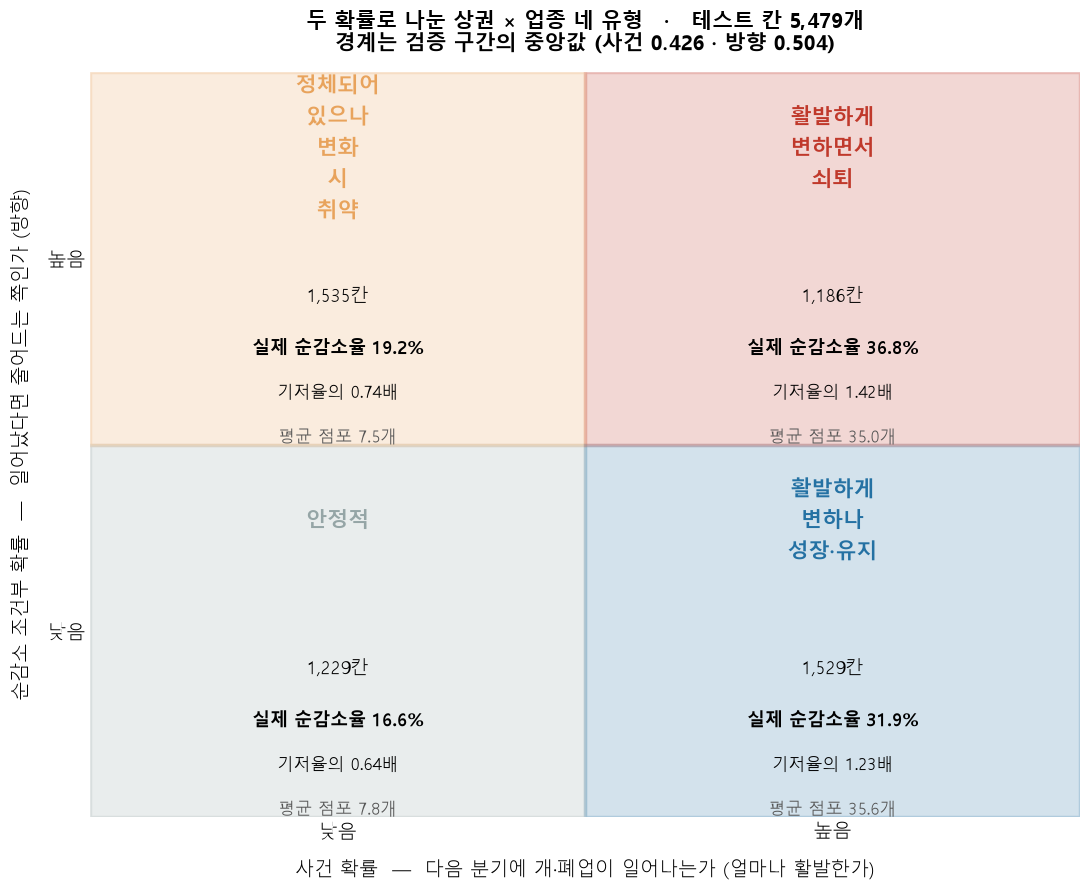

*그림 9*


읽는 법 — 오른쪽으로 갈수록 변화가 활발하고, 위로 갈수록 변할 때 줄어드는 쪽임.
  오른쪽 위가 가장 위험하고 왼쪽 아래가 가장 안전함.
  대각선 두 칸은 최종 위험도가 중간이지만 성격이 정반대이므로 대응이 달라야 함.

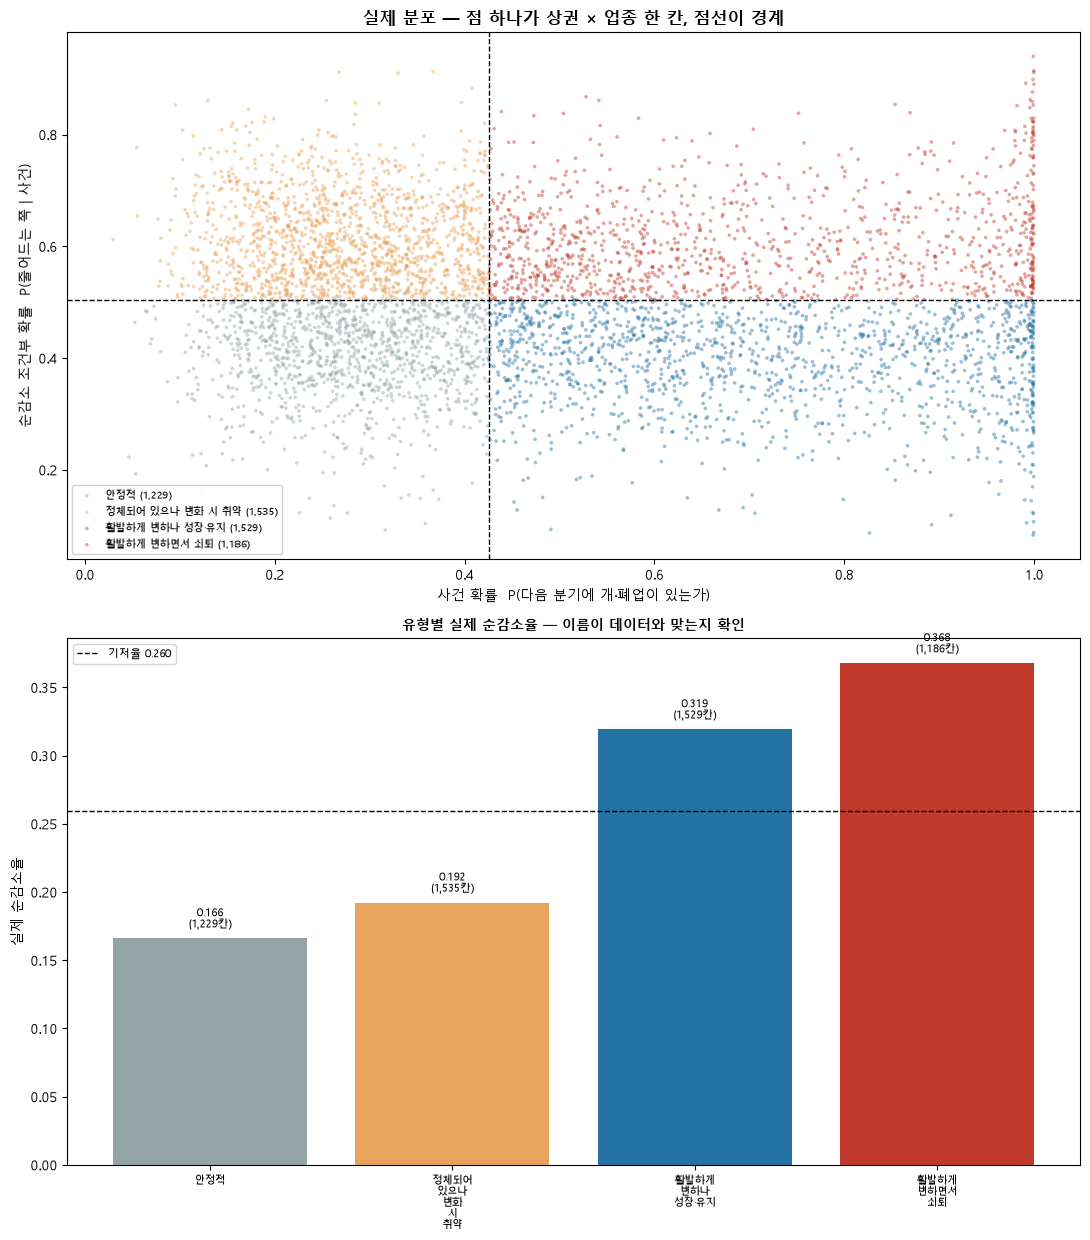

*그림 10*


가운데 두 유형 — 최종 위험도로 줄 세우면 어떻게 되는가

,유형,칸수,평균최종위험도,실제순감소율,평균점포
1,정체되어 있으나 변화 시 취약,1535,0.166,0.192,7.550
2,활발하게 변하나 성장·유지,1529,0.277,0.319,35.572


최종 위험도로 줄 세우면  «활발하게 변하나 성장·유지» 0.277  >  «정체되어 있으나 변화 시 취약» 0.166
평균 점포 수는           35.6개  vs  7.5개  (4.7배)

→ 곱 하나로 줄 세우면 «점포가 많은 쪽»이 앞에 오고, 작은 상권은 뒤로 밀림.
  그런데 뒤로 밀린 쪽이 «조용하지만 한 번 흔들리면 버티지 못하는» 유형임.
  칸 수가 비슷한데 성격이 정반대이므로, 하나의 순위로 합치면 이 구분이 사라짐.
  두 확률을 두 축으로 남겨 두어야 «어느 쪽에 어떤 대응이 필요한가»를 말할 수 있음.

표 72

골목상권만 떼어 유형 구성을 봄

,칸수,비중,실제순감소율
유형,,,
안정적,687,0.248,0.170
정체되어 있으나 변화 시 취약,963,0.347,0.188
활발하게 변하나 성장·유지,659,0.238,0.294
활발하게 변하면서 쇠퇴,463,0.167,0.322


골목상권 2,772칸 · 전체 순감소율 0.231

## 16. 무엇이 위험을 만드는가

모형이 자체로 내놓는 변수 중요도는 변수 사이의 의존성을 무시함. SHAP은 각 변수가 예측을 어느 방향으로 얼마나 밀었는지를 개별 예측 단위로 분해하므로 «무엇이 위험을 만드는가»에 답하기에 적합함.

규모·밀도 계열이 차지하는 기여 비중을 따로 계산함. 앞에서 본 «라벨이 규모에 끌려간다»는 우려가 모형에 얼마나 남아 있는지를 수치로 남기기 위함임.

2단계 모형은 단계별로 따로 SHAP을 내면 답이 갈라짐. 1단계는 무엇이 사건을 일으키는가를, 2단계는 사건이 났을 때 무엇이 줄어드는 쪽으로 미는가를 보여 줌. 2단계 상위에 오는 변수가 «크기와 무관하게 위험을 만드는 것»임. 곱을 한 장으로 합치는 것은 되지 않음 — SHAP은 기여를 더해서 설명하는데 최종 점수가 두 확률의 곱이기 때문임. 로그를 취하면 가법이 되므로 합산 기여도는 보조로 냄.



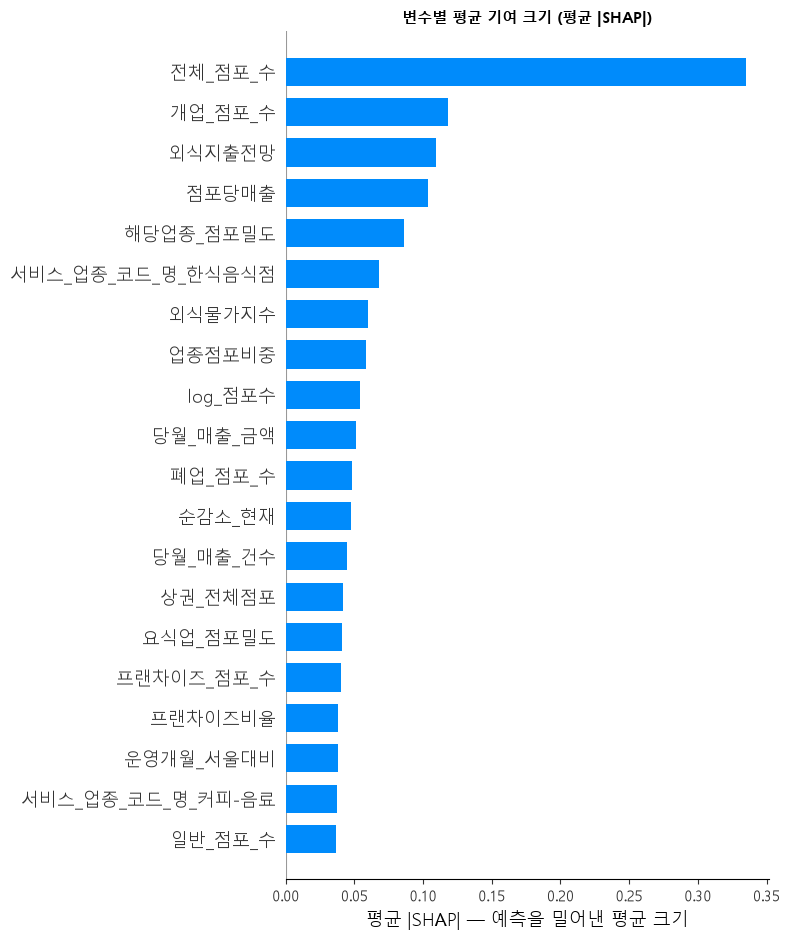

*그림 11*


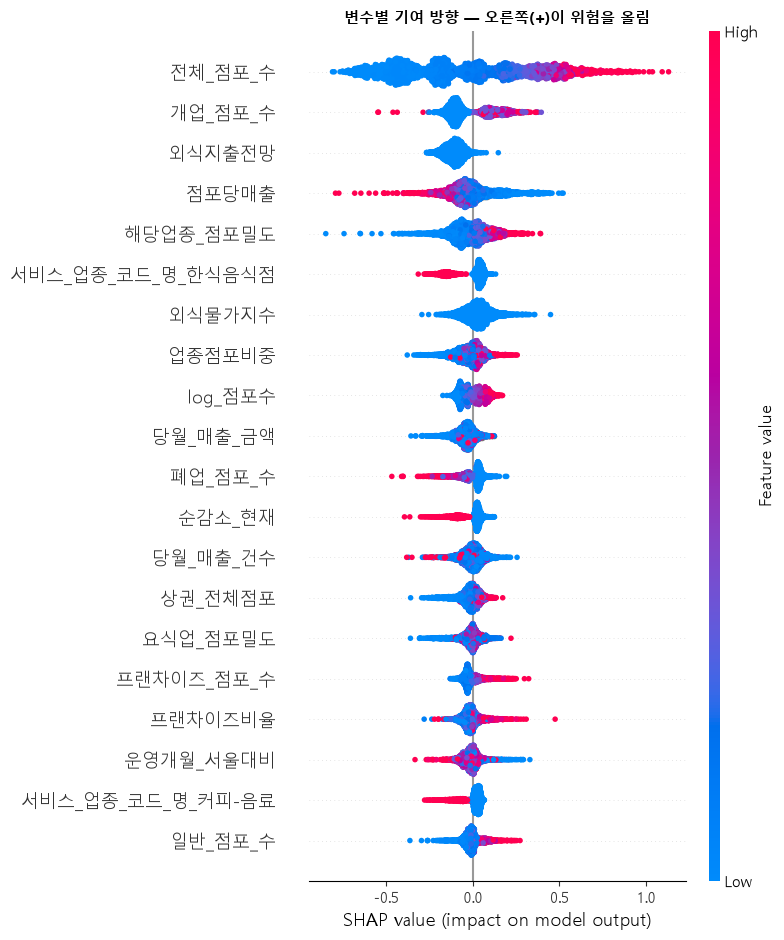

*그림 12*


,평균 |SHAP|
전체_점포_수,0.3350
개업_점포_수,0.1181
외식지출전망,0.1096
점포당매출,0.1033
해당업종_점포밀도,0.0863
서비스_업종_코드_명_한식음식점,0.0679
외식물가지수,0.0600
업종점포비중,0.0583
log_점포수,0.0543
당월_매출_금액,0.0515


규모·밀도 계열이 차지하는 기여 비중 53.1%
그 밖의 변수 46.9%

규모 계열 상위

,평균 |SHAP|
전체_점포_수,0.3350
개업_점포_수,0.1181
해당업종_점포밀도,0.0863
log_점포수,0.0543
폐업_점포_수,0.0483
상권_전체점포,0.0418
요식업_점포밀도,0.0406
프랜차이즈_점포_수,0.0405


규모 밖 상위

,평균 |SHAP|
외식지출전망,0.1096
점포당매출,0.1033
서비스_업종_코드_명_한식음식점,0.0679
외식물가지수,0.0600
업종점포비중,0.0583
당월_매출_금액,0.0515
순감소_현재,0.0474
당월_매출_건수,0.0443
프랜차이즈비율,0.0381
운영개월_서울대비,0.0378


규모·밀도 계열이 차지하는 기여 비중
  단일 모형          53.1%
  1단계 P(사건)       65.4%
  2단계 P(순감소|사건)  38.3%   ← 규모를 조건으로 걸었을 때 남는 몫

,1단계 |SHAP|,2단계 |SHAP|,1단계 순위,2단계 순위
log_면적,0.0092,0.0091,42,47
log_요식업밀도,0.0140,0.0196,38,32
log_유동인구,0.0190,0.0138,33,38
log_점포당매출,0.0183,0.0253,34,28
log_점포수,0.1302,0.0131,2,39
log_해당업종밀도,0.0092,0.0117,43,42
개업_점포_수,0.0633,0.1031,7,3
관공서_수,0.0047,0.0072,58,49
극장_수,0.0051,0.0032,57,63
당월_매출_건수,0.0514,0.0561,11,11


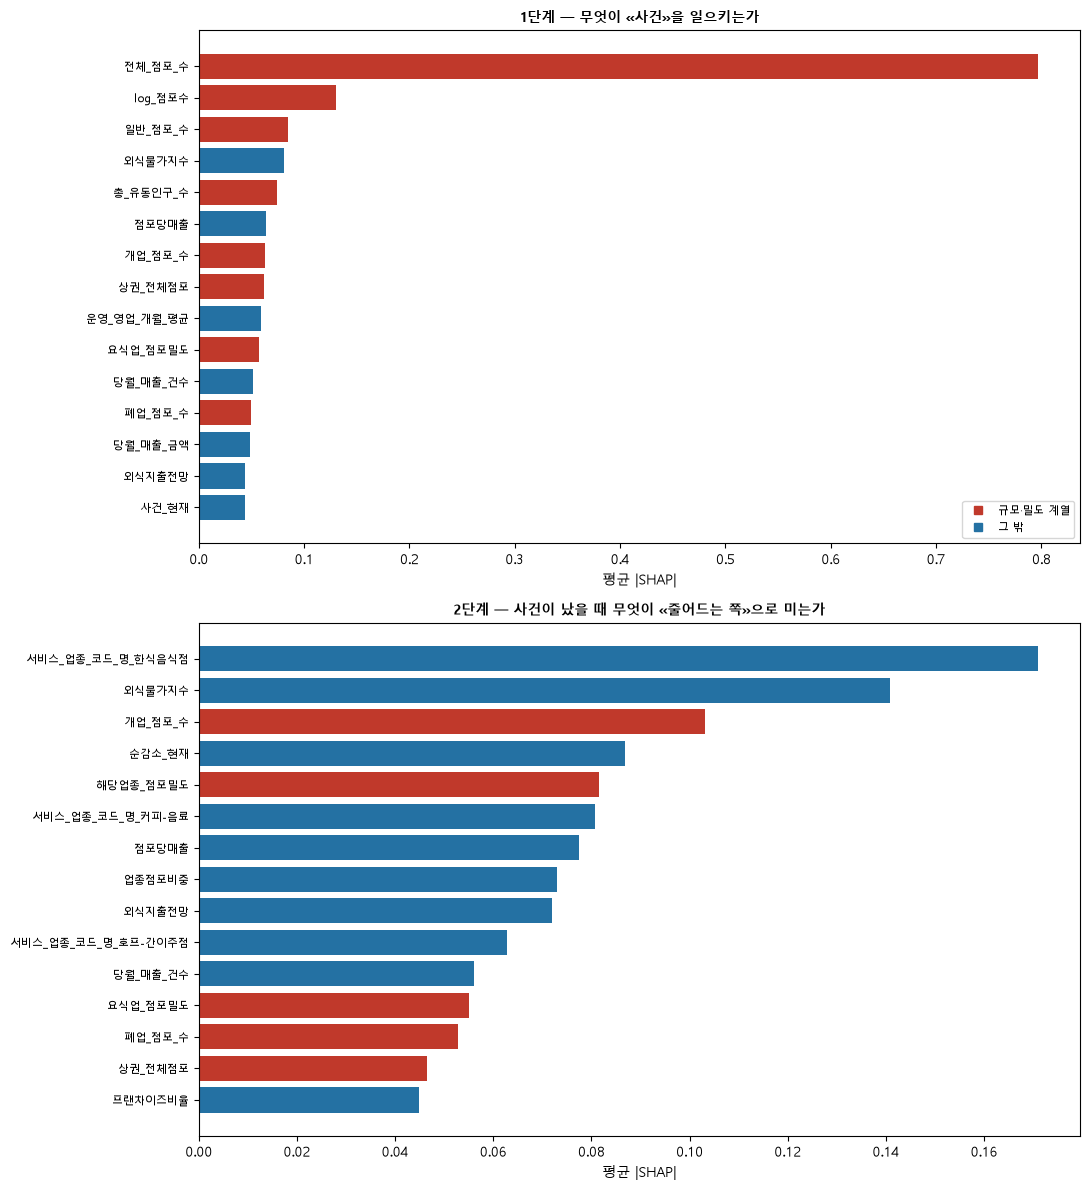

*그림 13*


2단계 상위 — 규모 계열을 뺀 목록 (규모를 조건으로 걸었을 때의 위험 요인)

,2단계 평균 |SHAP|
서비스_업종_코드_명_한식음식점,0.1710
외식물가지수,0.1408
순감소_현재,0.0869
서비스_업종_코드_명_커피-음료,0.0807
점포당매출,0.0775
업종점포비중,0.0730
외식지출전망,0.0720
서비스_업종_코드_명_호프-간이주점,0.0628
당월_매출_건수,0.0561
프랜차이즈비율,0.0450



보조 — 두 단계 기여를 더한 순위 (로그확률 기준, 상위 10)

,합산 |SHAP|
전체_점포_수,0.8361
외식물가지수,0.2215
서비스_업종_코드_명_한식음식점,0.2110
개업_점포_수,0.1664
log_점포수,0.1433
점포당매출,0.1419
총_유동인구_수,0.1184
해당업종_점포밀도,0.1171
외식지출전망,0.1163
요식업_점포밀도,0.1119


합산은 «두 단계 중 어디서든 많이 쓰인 변수»를 보여 줌.
규모 변수는 1단계에서, 그 밖의 변수는 2단계에서 올라오는 구조가 그대로 나타남.

## 17. 위험도 공간 분석

원본 좌표의 단위는 미터이고 좌표계는 EPSG:5181임. 지도 라이브러리가 알아듣는 것은 위경도이므로 변환이 필요하되, 두 벌을 유지함 — 그릴 때는 위경도, 거리를 잴 때는 원본 미터 좌표임. 위경도는 1도의 실제 길이가 위도마다 달라 뺄셈으로 거리를 구할 수 없음.

좌표계 검증은 실제로 어디인지 아는 상권으로 함. 후보 좌표계들이 서울 안에서 2km 이내로 붙어 있어 경계 상자만으로는 어느 것이 맞는지 갈라지지 않기 때문임. 지하철역 상권의 실제 위경도와 대조해 좌표계를 확정하고, 서울 경계 상자를 벗어나는 좌표가 없는지 함께 확인함.

위험등급은 보기 좋은 눈금이 아니라 위험점수의 4분위로 자름. 각 등급의 실제 순감소율을 붙여 그 등급이 정말 위험을 구분하는지 확인하고, 눈금으로 자르는 방식과 같은 데이터로 나란히 비교함.

상권 경계 폴리곤을 확보하지 못해 단계구분도는 그리지 못함. 좌표만으로 그릴 수 있는 버블 분포도·격자 분석·동심원 분석·공간 평활 네 레이어로 같은 질문에 답함.



,평균오차_km,최대오차_km
좌표계,,
EPSG:5181,0.284,0.489
EPSG:5174,0.561,0.799
EPSG:2097,0.559,0.799


검증 ① 기준점 6곳 대조 → 채택 좌표계 = EPSG:5181

,상권명,변환 경도,변환 위도,실제 경도,실제 위도,오차_km
기준점,,,,,,
홍대입구역,홍대입구역 3번,126.9256,37.5599,126.9237,37.5568,0.387
강남역,강남역,127.0278,37.4976,127.0276,37.4979,0.039
잠실역,잠실역,127.1013,37.5140,127.1000,37.5133,0.136
여의도역,여의도역(여의도),126.9263,37.5227,126.9244,37.5215,0.211
사당역,사당역 10번,126.9782,37.4794,126.9816,37.4765,0.445
노원역,노원역 9번,127.0632,37.6592,127.0611,37.6551,0.489


→ 강남역처럼 상권명이 역 이름 그대로인 곳은 오차 0.05km 안쪽. 좌표계가 맞음

검증 ② 서울 경계 상자 밖  0건 / 5,479건 (0.000%)
          경도 126.8020 ~ 127.1738 · 위도 37.4346 ~ 37.6898
          결측 좌표 0건

지도에 쓸 표본 5,479칸 (경계 상자 통과분만)

,칸수,평균위험점수,실제순감소율,평균점포,기저율대비
위험등급,,,,,
관찰,1370,0.209,0.153,8.547,0.59
주의,1370,0.345,0.194,12.060,0.75
경계,1369,0.461,0.299,19.187,1.15
위험,1370,0.643,0.393,45.672,1.51


«관찰» 15.3%  →  «위험» 39.3%   (2.6배)
→ 등급이 올라갈 때 실제 순감소율도 단조 증가하면 이 분류는 쓸 수 있음

눈금 기준 (현재 분기 순증감률 ±2%)

,칸수,실제순감소율,기저율대비
순증감률,,,
-2% 이하,1191,0.302,1.16
-2~0%,3213,0.214,0.82
0~+2%,98,0.459,1.77
+2% 이상,977,0.339,1.30


위험점수 4분위   단조 증가 예  · 기저율대비 폭 0.59 ~ 1.51
눈금 ±2% 기준    단조 증가 아니오  · 기저율대비 폭 0.82 ~ 1.77

→ ±2% 기준은 «0~+2%» 칸이 표본 98개뿐인데 순감소율이 가장 높게 튀어 순서가 뒤집힘.
   눈금으로 자른 경계가 실제 분포와 맞지 않는다는 뜻이고, 지도 색이 위험 순서를 나타내지 못함.
   위험점수 4분위는 네 등급이 모두 단조 증가하므로 지도에 그대로 쓸 수 있음.

배경 상권 1,422곳 · 자치구 외곽선 25개 생성
→ 외부 지도 자료 없이 좌표만으로 만든 배경임. 위치 파악용이며 면적 계산에는 쓰지 않음

상권 1,357곳 (각 상권의 최고 위험 업종 기준)

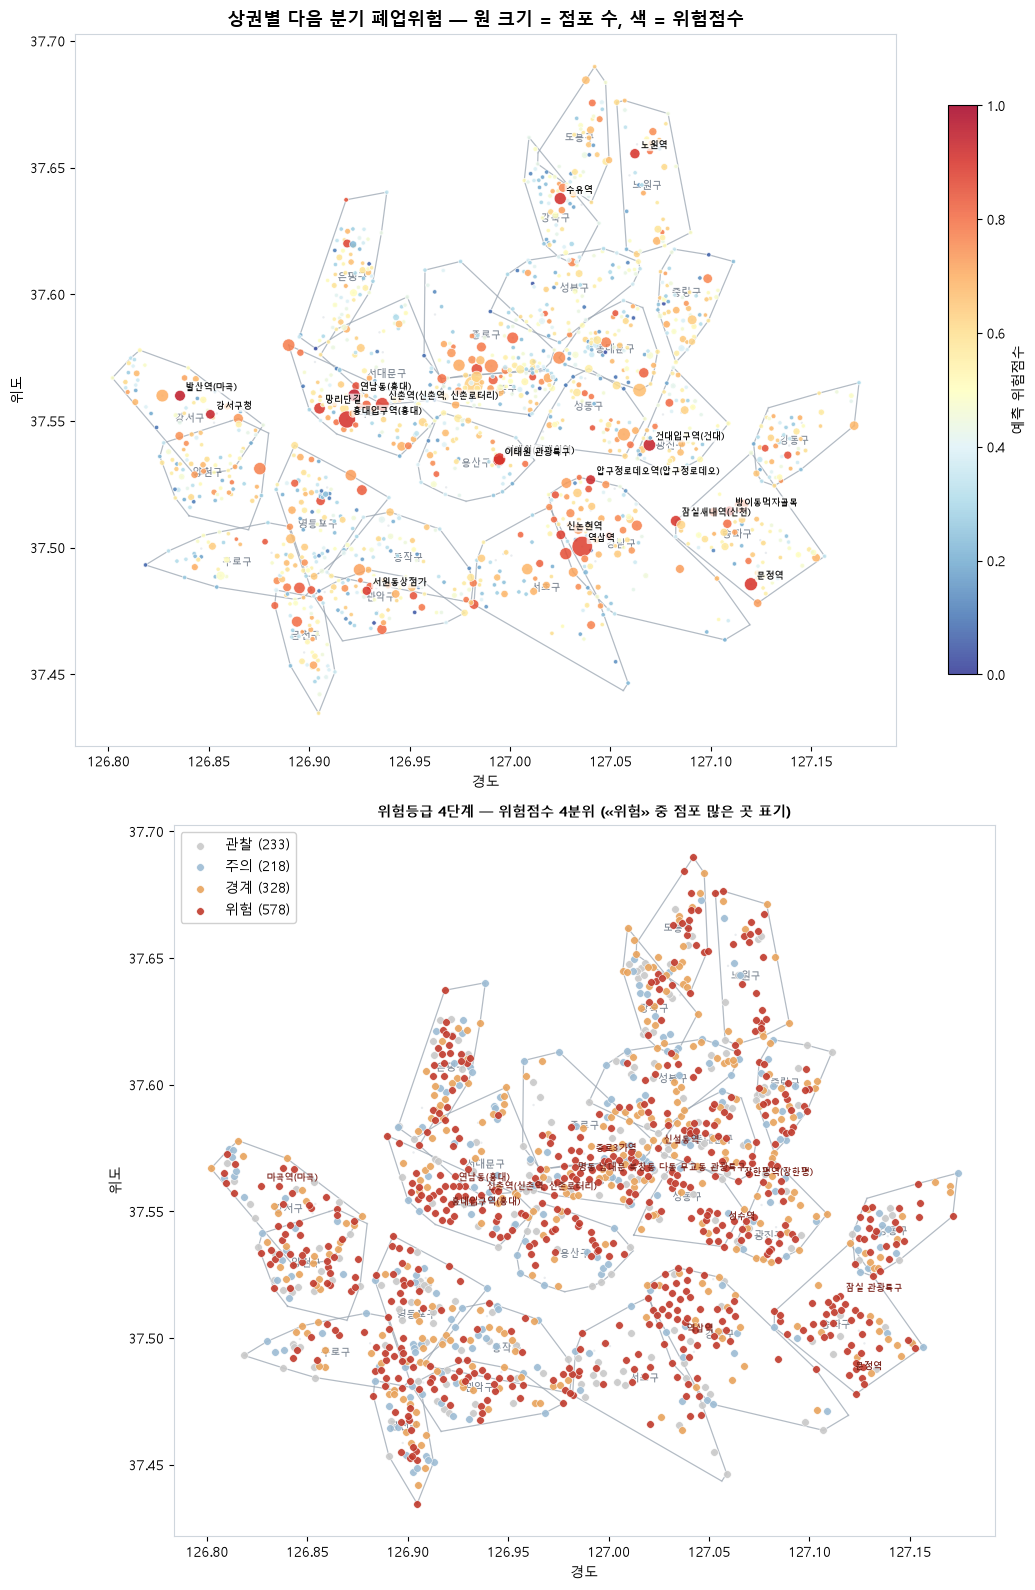

*그림 14*


왼쪽 그림에 위험점수 상위 18곳의 상권명을 표기함

500m 격자 678개 (칸 3개 이상) · 전체 격자 대비 74%

,gx,gy,칸수,평균위험,실제순감소율,점포합,자치구
0,370,902,10,0.817,0.500,925.0,강서구
1,410,923,10,0.714,0.500,728.0,노원구
2,385,900,10,0.695,0.500,1304.0,마포구
3,421,885,10,0.692,0.400,762.0,송파구
4,407,899,4,0.685,0.500,77.0,성동구
5,407,894,9,0.676,0.444,534.0,강남구
6,406,889,10,0.664,0.500,1020.0,강남구
7,404,888,10,0.660,0.400,1295.0,서초구
8,393,895,10,0.658,0.400,667.0,용산구
9,388,901,10,0.658,0.400,938.0,서대문구


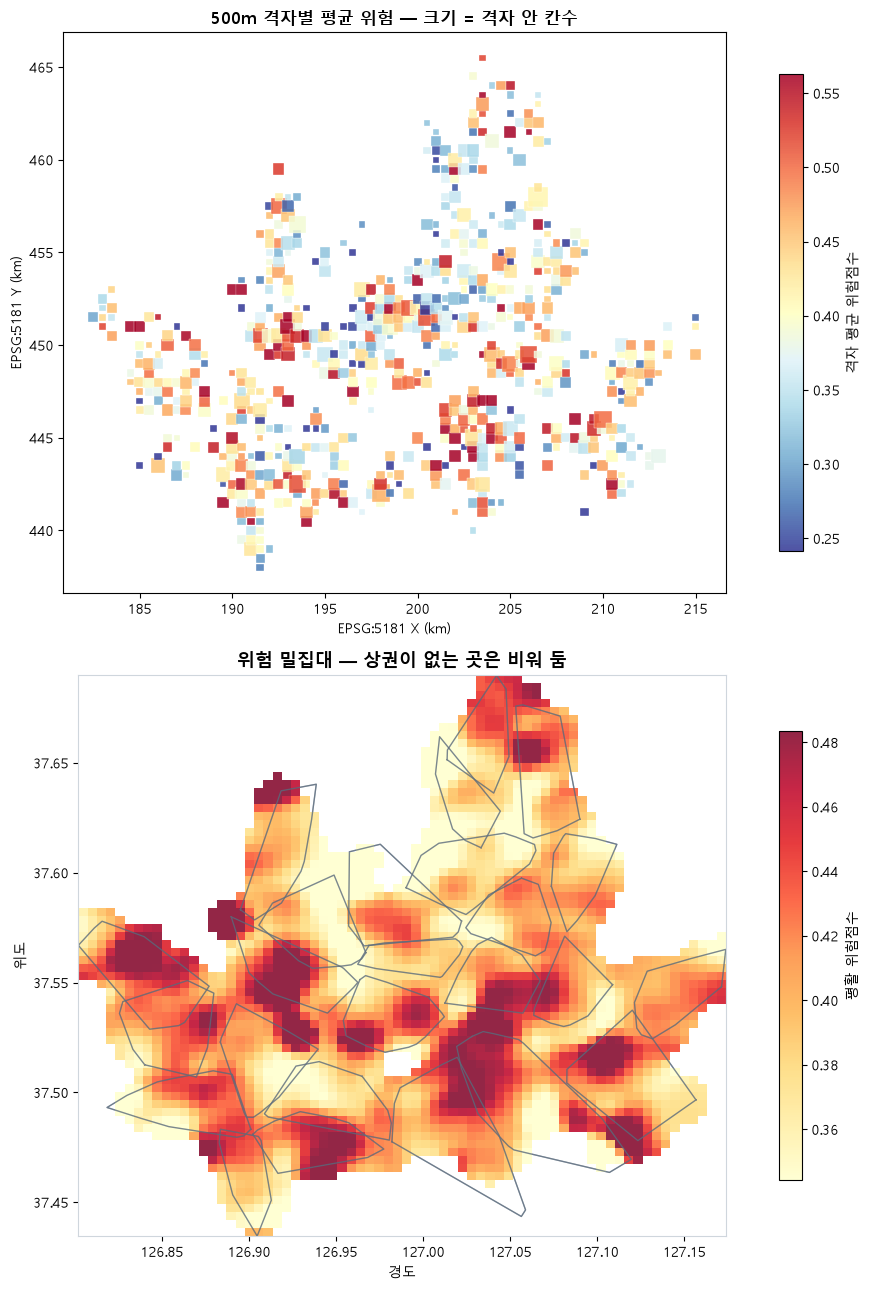

*그림 15*


역세권 상권(대리 거점) 191곳

,상권수,평균위험,실제순감소율,평균점포
역거리_구간,,,,
역세권 상권,191,0.623,0.414,53.419
0~250m,66,0.430,0.227,19.212
250~500m,370,0.475,0.273,21.095
500m~1km,519,0.468,0.295,21.383
1km 초과,211,0.434,0.294,18.569


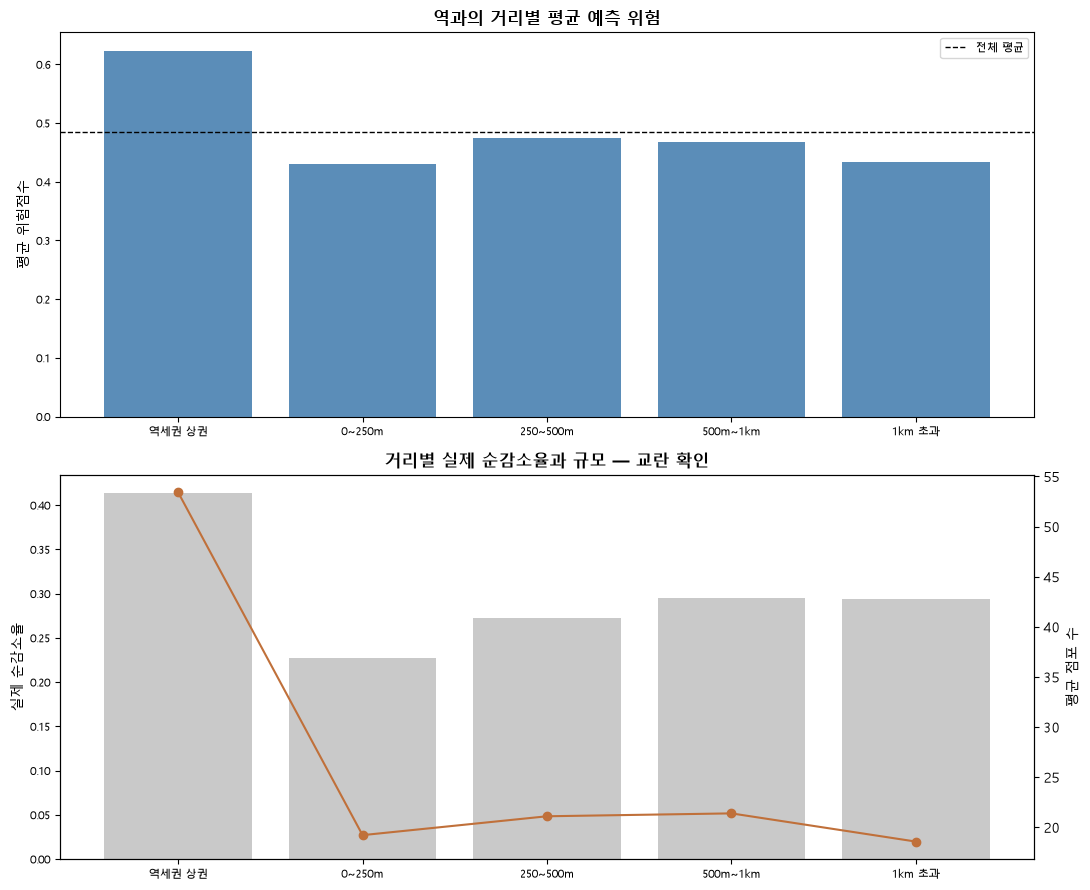

*그림 16*


역세권 상권 자체    평균 점포 53.4개 · 평균 위험 0.623
역 밖 구간 4개      평균 점포 18.6~21.4개 · 평균 위험 0.430~0.475

→ 결론: 거리 구배가 없음. 역 밖 네 구간의 위험이 0.46~0.50으로 사실상 평평하고,
   250m~1km 구간이 0~250m 구간보다 오히려 높아 순서도 맞지 않음.
   유일하게 두드러지는 것은 «역세권 상권 자체»인데 그 상권들의 평균 점포가
   2.4배 이상 크므로, 이것은 거리 효과가 아니라 규모 효과임.
   → 동심원 레이어는 «역과의 거리는 위험을 설명하지 못한다»는 음성 결과로 보고함.

## 18. 종합 결론

먼저 가설별 검정 결과를 한자리에 모음. 통계적으로 유의한지, 그리고 그 유의성이 실질적 크기를 가지는지 두 가지를 함께 적음. 표본이 수만 건이라 p-value 만으로는 판단할 수 없기 때문임.

**Q1 — 다음 분기 순감소 전환을 예측할 수 있는가.** 지지됨. 다만 «어느 작동점에서»라는 조건이 붙음. 검증에서 정한 상위 100칸에서 정밀도 0.600 으로 기저율 0.260 의 2.31배임. 홀드아웃 분기에서 얻은 값이고, 위험등급 네 단계의 실제 순감소율이 15.3% → 39.3% 로 단조 증가해 순위가 실제 위험과 맞음. 반면 기저율과 같은 비율(전체의 23%)을 찍는 설정에서는 «점포 수» 규칙보다 낮음. **따라서 «예측 가능하다»는 결론은 상위 소수를 찍는 운영 조건에 한정됨.**

**Q2 — 상권유형에 따라 위험이 다른가. 유형 자체인가, 규모·입지 차이인가.** 조건부로 지지됨. 점포 수를 층으로 통제한 CMH 검정에서 유의함(chi2(1)=9.834, p=0.0017). 층을 통제하지 않은 단순 오즈비는 0.813 이었으나 공통 오즈비는 1.061 [1.023, 1.101] 로 **부호가 뒤집힘.** 즉 골목상권이 안전해 보였던 것은 규모 교란이었음. **다만 층별 오즈비의 동질성이 성립하지 않아**(Woolf Q=27.387, p=0.0000166) 하나의 값으로 요약할 수 없음. 작은·중간 규모에서는 골목상권이 더 위험하고(1.09~1.17) 가장 큰 규모에서는 반대임(0.89).

**Q2 보강 — 업종 수준에서도 같은 구조인가.** 지지됨. 한식음식점을 처리군으로 성향점수매칭을 하면 단순 격차 +2.38%p 가 ATT −5.46%p 로 뒤집힘. McNemar p=0.000000000000311, 상권 단위 클러스터 부트스트랩 95% CI [−6.77%p, −3.81%p] 로 0을 포함하지 않으며, 캘리퍼와 복원 여부를 바꾼 다섯 설계에서 부호가 모두 같음(−5.59 ~ −4.43%p). **«업종 자체의 위험»으로 보였던 것은 그 업종이 큰 상권에 몰려 있다는 사실이었음.**

**Q3 — 동일 업종이라도 상권유형에 따라 다른가.** 부분 지지됨. 열 업종 중 여덟이 Bonferroni 보정 기준을 통과함. 그러나 효과크기가 업종마다 크게 달라 호프-간이주점은 ε²=0.1202(중간 이상)인 반면 치킨전문점은 0.0002 로 사실상 0이며 유의하지도 않음. **«모든 업종이 입지에 민감하다»는 진술은 성립하지 않음.** 업종별로 나누어 말해야 함.

**자치구 효과 — 기각에 가까움.** 골목상권 안에서 자치구 쌍별 비교를 하면 가능한 300쌍 중 유의한 쌍이 3개(1.0%)뿐임. 대부분의 자치구가 서로 구분되지 않는 중간군을 이룸. **위험을 말할 단위는 자치구가 아니라 상권임.**

**상권유형 사후검정 — 여섯 쌍 중 다섯 쌍이 유의함.** 전통시장 ↔ 골목상권만 갈리지 않음(p=0.321). 두 유형이 위험 수준에서 같은 자리에 있으므로 하나의 묶음으로 다루어도 무리가 없음. 순위는 전통시장 < 골목상권 = 발달상권 < 관광특구 임.

**검정 방법의 전제 — 위배됨.** 상권유형 4/4, 업종 10/10, 자치구 25/25 그룹에서 정규성이 기각됨. 등분산성은 상권유형·업종은 위배이고 자치구만 성립함(Levene p=0.073). 분포가 오른쪽으로 꼬리가 길어(왜도 +0.592) 평균 비교가 불리하므로 **주 검정을 Kruskal-Wallis 로 한 것이 이 결과에서 나온 선택임.**

핵심 질문은 «다음 분기에 점포 순감소로 전환될 상권 × 업종은 어디이며, 무엇이 위험을 만드는가»였음. 두 부분으로 나누어 답함.

**어디인가** — 조기경보로 쓸 수 있는 순위가 나옴. 검증에서 정한 작동점(상위 100칸)을 테스트에 옮기면 정밀도 0.600 으로 기저율 26.0% 의 2.31배임. 상위 50칸으로 좁히면 0.720 까지 올라감. 이 목록은 «점포 수가 많은 순»과 10~23% 만 겹치므로, 크기만 보고는 찾을 수 없는 곳을 지목함. 가장 위험한 칸은 발달상권의 호프-간이주점에 몰려 있고, 자치구 기준 위험 비중은 송파·성동·마포 순임.

**무엇이 위험을 만드는가** — 단일 모형의 기여도는 규모·밀도 계열이 절반을 넘어(53.1%) «점포가 많으면 위험»이라는 답밖에 나오지 않음. 사건 발생과 방향을 두 단계로 나누면 그 의존이 1단계에 몰리고(65.4%) 2단계에서 38.3% 로 떨어짐. 따라서 «크기와 무관한 위험 요인»은 2단계 상위 변수에서 읽어야 함. 점포당 매출, 업종 구성, 업종 자체가 그 자리에 옴.

**이 과제에서 가장 조심해야 했던 것은 라벨의 구조였음.** `y=0` 의 절반이 넘는 수가 «변화 없음»이고, 그것은 안전해서가 아니라 작아서 아무 일도 관측되지 않은 것임. 평균 점포 5.4개 구간에서는 열 칸 중 일곱 칸이 그러하고, 65.5개 구간에서는 한 칸도 되지 않음. 아무 처리도 하지 않으면 모형은 «위험한 조건»이 아니라 «사건이 일어날 만한 크기»를 배움. 점포 수 구간별 재계산, 사건과 방향의 분리, 두 축 유형화가 모두 이 문제에서 나온 대응임.

**성능은 작동점을 정한 뒤에만 말할 수 있음.** 기저율과 같은 비율(전체의 23%)을 찍는 설정에서는 «점포 수» 규칙이 더 높게 나오고, 상위 소수를 찍는 설정에서는 모델이 더 높음. 많이 찍으면 결국 큰 상권을 모두 담게 되어 두 방법이 같아지기 때문임. 조기경보는 손이 닿는 수십~수백 곳을 고르는 운영이므로 그 구간의 값이 실무 성능임. 한 작동점만 떼어 보면 결론의 방향이 반대로 읽히므로, 작동점별·구간별·전체 세 표를 함께 보고해야 함.

**점포 수 구간별로 보면 모델이 같거나 높음.** 특히 가장 작은 1분위에서 «점포 수» 규칙은 0.981 로 무작위 아래로 떨어지는데 모델은 1.338 임. 점포가 적은 상권들 사이에서는 크기가 아무 정보를 주지 못하고, 조기경보가 실제로 필요한 대상이 그 구간임.

**서울시 공식 상권변화지표는 무작위보다 낮았음**(Lift 0.937). «HL 상권축소»로 진단된 칸을 위험으로 찍는 것이 아무렇게나 찍는 것보다 못하다는 뜻이며, 그 지표가 지금까지의 상태를 요약할 뿐 다음 분기를 겨냥하지 않기 때문으로 보임. 기존 지표를 대체할 근거가 여기서 나옴.

**보조 질문(상권유형·업종에 따라 위험이 다른가)은 조건을 맞추기 전과 후가 정반대였음.** 한식음식점은 단순 비교에서 다른 업종보다 2.38%p 위험해 보였으나, 규모·유동인구·면적·집객시설을 맞춰 짝지으면 오히려 5.46%p 안전함. McNemar 검정과 상권 단위 부트스트랩 신뢰구간, 설계를 바꾼 다섯 경우가 모두 같은 방향을 가리킴. 위험해 보였던 것은 업종의 성질이 아니라 그 업종이 큰 상권에 몰려 있다는 사실이었음.

**골목상권도 같은 구조였음.** 층을 통제하지 않으면 골목상권이 안전해 보이나(오즈비 0.813), 점포 수 5분위를 통제하면 방향이 뒤집힘(공통 오즈비 1.061, CMH p=0.0017). 다만 층별 오즈비의 동질성이 성립하지 않으므로(Woolf p=0.0000166) 하나의 값으로 요약할 수 없음. 작은·중간 규모에서는 골목상권이 더 위험하고(1.09~1.17) 가장 큰 구간에서는 오히려 안전함(0.89). **단순 집계만으로 «어느 유형이 위험하다»고 말하면 방향이 반대로 나올 수 있다는 것**이 이 분석의 가장 실무적인 교훈임.

**위험을 말할 단위는 자치구가 아니라 상권임.** 자치구 사이의 쌍별 비교에서 유의한 쌍이 300개 중 3개뿐이었음. 대부분의 자치구가 서로 구분되지 않는 중간군을 이루므로, 행정 경계로 묶어 대응하면 같은 구 안의 위험한 상권을 놓치게 됨. 상권유형은 여섯 쌍 중 다섯 쌍이 갈리되 전통시장과 골목상권은 구분되지 않아, 두 유형을 하나의 묶음으로 다루어도 무리가 없음.

**두 확률을 두 축으로 남긴 것이 이 분석의 정책적 산출물임.** 최종 위험도는 두 확률의 곱이므로 하나의 순위로 줄 세우면 사건 확률이 높은 쪽 — 즉 점포가 많은 상권이 앞으로 오고 작은 상권은 뒤로 밀림. 그런데 뒤로 밀리는 쪽에 «조용하지만 한 번 흔들리면 버티지 못하는» 유형이 들어 있고, 골목상권에서는 그 유형이 34.7% 로 가장 큰 비중임. 순위 하나로 합치면 이 구분이 사라짐.

네 유형은 대응이 서로 달라야 함. **활발하게 변하면서 쇠퇴하는 상권**은 이미 빠져나가는 중이므로 즉시 개입 대상임. **정체되어 있으나 변화 시 취약한 상권**은 지금은 조용하나 충격에 약하므로 선제적으로 지켜볼 대상임. **활발하게 변하나 성장·유지되는 상권**은 회전이 빠른 것이 정상이므로 개입 우선순위가 낮음. **안정적인 상권**은 관찰만으로 충분함.

**모델 선택은 이 문제에서 결론을 바꾸지 않음.** 성격이 다른 다섯 계열의 AP 가 0.398~0.408 에 몰려 있음. 선형 모형과 부스팅의 차이가 거의 없다는 것은 복잡한 상호작용으로 얻을 몫이 적다는 뜻이며, 성능의 한계가 알고리즘이 아니라 쓸 수 있는 변수에 있음을 말함. 따라서 판단 기준은 해석 가능성이 되고, 기여를 정확히 분해할 수 있는 쪽을 택함.

**전체를 줄 세우는 능력은 점포 수 하나와 거의 같음.** 이것을 «예측이 안 된다»로 읽으면 안 됨. 상위 소수 구간에서는 모델이 분명히 높고 위험등급도 실제 순감소율과 단조로 맞음(15.3% → 39.3%). 정확한 진술은 «현재 피처 집합이 규모 이상을 크게 담지 못한다»이며, 그 한계의 위치를 수치로 짚은 것 자체가 결과임.

**변수를 늘리려면 상권 단위로 다르게 측정된 값이 필요함.** 전국 단위 지표는 한 분기 안에서 모든 칸이 같은 값을 받으므로 순위를 바꾸지 못함. 기여도 순위에 높게 오르더라도 그것은 학습 구간에서 분기를 구분하는 데 쓰였다는 뜻일 뿐임. 임대료·상권별 온라인 관심도처럼 상권 단위로 변하는 자료를 상권 코드에 결합할 수 있게 되면 그때 성능이 움직일 여지가 있음.

**분석 결과를 «누가 · 무엇을 · 어떤 순서로»로 옮김.** 아래는 이 분석에서 나온 근거만으로 세울 수 있는 것이고, 근거가 없는 항목은 넣지 않음.

**① 경보 대상을 상위 100~300칸으로 한정함.** 정밀도가 상위 100칸에서 0.600, 300칸에서 0.533 이고 그 아래로는 «점포 수 순»과 값이 가까워짐. 담당 인력이 한 분기에 실제로 접촉할 수 있는 수를 정한 뒤 그 개수만큼 잘라 쓰는 것이 맞음. 다만 상위 100칸은 실제 위험 칸의 4% 정도만 포착하므로, «전수 관리»가 아니라 «우선 접촉 목록»으로 쓴다는 것을 전제해야 함.

**② 유형별로 지원 수단을 달리 배정함.** 네 유형이 같은 위험도로 묶이더라도 필요한 처방이 다름.

  **활발하게 변하면서 쇠퇴**(1,186칸 · 평균 점포 35개) — 이미 순유출이 진행 중인 상권임. 즉시 개입 대상이며, 이 유형은 규모가 커서 한 건당 영향 범위가 넓음. 임차료·대출 등 비용 측면의 단기 완충이 우선임.

  **정체되어 있으나 변화 시 취약**(1,535칸 · 평균 점포 7.6개 · 골목상권 내 34.7%) — 평소 개·폐업이 거의 없어 기존 지표로는 «조용한 상권»으로 분류되나, 변화가 생기면 줄어드는 쪽으로 갈 확률이 높음. **최종 위험도 순위에서는 뒤로 밀리므로 별도 명단으로 관리해야 함.** 소규모 점포 중심이므로 개별 컨설팅·판로 지원처럼 단가가 낮고 건수를 늘릴 수 있는 수단이 맞음.

  **활발하게 변하나 성장·유지**(1,529칸) — 회전이 빠른 것이 정상 상태임. 개입 우선순위가 낮고, 신규 진입을 돕는 정보 제공 쪽이 적합함.

  **안정적**(1,229칸) — 관찰만으로 충분함. 예산을 배정하지 않는 것이 이 유형에 대한 결정임.

**③ 대응 단위를 자치구가 아니라 상권으로 바꿈.** 자치구 쌍별 비교에서 유의한 쌍이 300개 중 3개뿐이었음. 자치구 단위로 예산을 나누면 같은 구 안의 위험한 상권과 안전한 상권이 같은 취급을 받음. 위험등급 4단계가 실제 순감소율과 단조로 맞으므로(15.3% → 39.3%), **등급을 배정 단위로 쓰는 것이 행정 경계로 나누는 것보다 근거가 있음.** 자치구는 집행 창구로만 쓰고 대상 선정은 상권 단위로 함.

**④ 업종별로 접근을 나눔.** 상권유형 효과크기가 업종마다 크게 달랐음. 호프-간이주점(ε²=0.1202)은 입지에 민감하므로 상권 단위 대응이 유효하나, 치킨전문점(ε²=0.0002)은 어디에 있든 위험 수준이 비슷해 입지 기반 대응의 효과가 낮음. **후자에는 상권이 아니라 업태 차원의 수단(배달 수수료·원가 등)이 맞음.** 다만 이 분석은 그 수단의 효과를 검증하지 않았으므로 방향 제시에 그침.

**⑤ 기존 지표를 대체할 근거가 확보됨.** 서울시 상권변화지표의 «HL 상권축소» 진단으로 위험을 찍으면 Lift 0.937 로 무작위보다 낮았음. 그 지표는 지금까지의 상태를 요약하는 데는 유효하나 다음 분기를 겨냥한 선별에는 쓸 수 없음. **조기경보 목적에서는 이 모델의 위험등급으로 교체하는 것이 근거상 타당함.** 다만 대체가 아니라 병용하여 두 지표가 어긋나는 상권을 따로 보는 것도 방법임.

**⑥ 분기마다 갱신하고 성능을 다시 잼.** 테스트가 한 분기이므로 지금 수치는 그 분기의 성적임. 새 분기 데이터가 들어오면 같은 절차로 다시 학습하고, **작동점을 그 분기의 검증 구간에서 다시 고름.** 성능이 떨어지면 원인을 «변수의 한계»와 «관계의 변화»로 나누어 확인해야 함.

**기대효과** — 이 분석이 실제로 바꾸는 것은 세 가지임. 첫째, **한 분기 앞선 선별**이 가능해짐. 지금까지 이미 순감소가 확인된 뒤에 대응했다면 그보다 한 분기 먼저 명단을 얻음. 둘째, **규모에 가려져 있던 대상이 드러남.** 작은 상권들 사이에서는 점포 수가 아무 정보를 주지 못하는데, 그 구간에서 모델이 무작위 아래로 떨어지는 규칙을 대신함. 셋째, **잘못된 방향의 결론을 막음.** 규모를 통제하지 않은 단순 집계는 «어느 유형·업종이 위험한가»에 대해 부호가 반대인 답을 내놓았고, 이 분석이 그것을 두 번 확인했음.

**한계 — 발표에서 먼저 밝혀야 하는 다섯 가지임.** 첫째, «폐업»은 실제 폐점이 아니라 사업자등록 말소 시점이므로 시차가 있음. 둘째, 매출은 카드 결제 기반 추정치이고 결제가 잡히지 않는 영세 칸은 결측임. 셋째, 테스트가 한 분기이므로 여기서 나온 값은 그 분기의 성적이며 분기를 늘려 재확인해야 함. 넷째, 상권 경계 폴리곤을 확보하지 못해 단계구분도를 그리지 못했고, 자치구 경계는 상권 좌표의 볼록 껍질로 근사한 것이므로 면적 계산에는 쓸 수 없음. 다섯째, 역과의 거리는 위험을 설명하지 못했으며 «역»의 위치도 지하철역이 있는 상권의 중심점을 대리로 쓴 것임.



### 남는 질문

**개별 점포 단위로 다시 세울 수 있는가.** 지금 데이터는 상권 × 업종 × 분기로 이미 집계되어 있어 역산이 불가능함. 인허가 원자료를 받아 지오코딩과 상권 매칭을 새로 하면 «어떤 점포가 위험한가»까지 내려갈 수 있고, 그 단위에서는 개업 시점이 행마다 달라지므로 전국 경제지표도 판별력을 가질 수 있음.

**두 축 유형이 시간에 따라 어떻게 옮겨 다니는가.** 지금은 한 분기의 스냅숏임. 같은 상권이 «안정적»에서 «정체·취약»으로 넘어가는 시점을 잡아낼 수 있다면, 그것이 조기경보의 다음 형태임.

**동질성이 깨진 이유.** 가장 큰 구간에서만 골목상권의 방향이 반대인 것이 무엇 때문인지는 이 분석으로 답하지 못함. 큰 골목상권이 사실상 발달상권처럼 작동하는 것인지, 다른 이유가 있는지는 그 구간만 따로 들여다봐야 함.

